# 백혈구(WBC) 4종 분류 — 원본 이미지 기반 최종본

**2조 프로젝트** / 데이터: Kaggle `paultimothymooney/blood-cells`
교재: **딥러닝의 정석 with 파이토치** (수업 1~5장) + 영상처리 과목

---

## 이 노트북의 설계 결정 세 가지

### ① 원본 354장만 쓴다 — 누수를 원천 차단하기 위해

이 데이터셋에는 두 벌이 있다.

| | 장수 | 정체 |
|---|---|---|
| `dataset-master/JPEGImages` | **366장** | 촬영 원본 |
| `dataset2-master` | 12,444장 | **위 366장을 회전·이동·확대해 불린 것** |

증강본을 쓰면 **같은 원본에서 나온 형제 사진이 학습과 시험에 나뉘어 들어갈 수 있다.**
그러면 시험 점수는 일반화 성능이 아니라 **암기력**을 잰 것이 된다.

원본 한 장은 곧 하나의 촬영이므로, **원본을 나누는 순간 형제가 생길 수 없다.**
증강본을 쓰면 어떤 일이 벌어지는지는 **§20 부록**에서 숫자로 보여 준다.

### ② 베이스라인은 수업 4장의 3단 구조를 그대로 따른다

수업 4장(헬멧 안전 분류)이 **정확히 이 프로젝트와 같은 상황**이다 — 적은 데이터, 클래스 불균형, 커스텀 Dataset.
그 장의 목차가 곧 우리 실험 설계다.

| 수업 4장 | 그 절의 역할 | 이 노트북 |
|---|---|---|
| **4-2 클래스 불균형 확인** | 다수 클래스 비율 | **기준선 0** — 전부 호중구로 찍기 |
| **4-4 밑바닥 CNN — 기준선** | 노트에 "기준선"이라 명시 | **A. SimpleCNN** (구조는 3-12) |
| **4-6 전이학습** | 학습 파라미터 1,281 vs 2,376만 | **B. 백본 고정** |
| **4-7 클래스 가중치 — 불균형에 답하기** | `pos_weight` | **C. 미세조정 + 클래스 가중치** |
| **"세 모델 비교 — 이 장의 결론"** | 4장의 결론 구조 | §10 과 §21 의 결론표 |

### ③ 배운 것만 쓴다 — 안 배운 것은 배운 것으로 대체했다

| 흔히 쓰지만 수업에 없는 것 | 이 노트북의 대체 |
|---|---|
| K-Fold 교차검증 | **시드를 바꾼 층화분할 반복** (4-3 의 `train_test_split(random_state=)`) |
| ROI 자동 검출 (모폴로지·연결성분) | **쓰지 않는다.** 원본만 쓰므로 화각을 맞출 필요가 없다 |
| `CenterCrop` | `Resize` 만 쓴다 (3-13, 5-2 에 있는 것) |
| 온도 스케일링 | **임계값 스윕** (`5.ipynb` 의 민감도-특이도 절충 방식) |

> **검색으로 확인한 사실**: `Grad-CAM` 구현은 `17-deep-learning/5.ipynb` 안에 있다(정리노트에는 없다).
> 그래서 §17 은 그 코드를 **다중 분류용으로만 고쳐** 쓴다.
> 반대로 모폴로지·연결성분·KFold·CenterCrop 은 정리노트와 실습 파일 어디에도 없어 쓰지 않는다.

---

## 목차

| § | 내용 | 에폭 |
|---|---|---|
| 1 | 실행 설정 | |
| 2 | 준비 — 환경·시드 | |
| 3 | 라벨 품질 감사 + 불균형 → **기준선 0** | |
| 4 | 이미지 관찰 (+ 소벨 필터) | |
| 5 | 전처리와 증강 | |
| 6 | 층화 3분할 + 커스텀 Dataset | |
| 7 | 모델 3종 | |
| 8 | 학습 루프와 평가 함수 | |
| 9 | 속도 프로브 (1 에폭 3분) | |
| 10 | **실험 1 — 베이스라인 3단 비교** | ○ |
| 11 | 실험 2 — 에폭 수 결정 | ○ |
| 12 | 실험 3 — 증강 비교 | ○ |
| 13 | 실험 4 — 하이퍼파라미터 | ○ |
| 14 | 최종 설정 확정 (검증셋 기준) | |
| 15 | **최종 평가 — 반복 홀드아웃 5회** | ○ |
| 16 | 대표 1회 상세 평가 | |
| 17 | Grad-CAM | |
| 18 | 확신도 임계값 (보류 정책) | |
| 19 | 가설검정 | |
| 20 | 부록 — 증강본 12,444장을 왜 안 쓰는가 | ○ |
| 21 | 최종 결론 | |

---
# §1. 실행 설정

원본 354장이라 데이터가 작다. 그래서 전체가 GPU 기준 **30분~1시간**이면 끝난다.

In [1]:
RUN_LEVEL = 'full'          # 'test' | 'full'

PROFILE = {
    'test': dict(screen_epochs=2,  full_epochs=3,  seeds=[42, 0, 1],          image_size=160),
    'full': dict(screen_epochs=15, full_epochs=40, seeds=[42, 0, 1, 2, 3],     image_size=224),
}[RUN_LEVEL]

SCREEN_EPOCHS = PROFILE['screen_epochs']   # 후보 비교용
FULL_EPOCHS   = PROFILE['full_epochs']     # 본 학습용
SEEDS         = PROFILE['seeds']           # 반복 홀드아웃에 쓸 시드 (첫 번째는 SPLIT_SEED 와 같게 둔다)
IMAGE_SIZE    = PROFILE['image_size']
BATCH_SIZE    = 16          # 354장이라 배치를 작게 잡는다
NUM_WORKERS   = 0           # 윈도우 주피터에서는 0 이 가장 안전하다 (데이터가 작아 느리지 않다)
EPOCH_BUDGET  = 180         # 과제 조건: 1 에폭 최대 3분
SPLIT_SEED    = 42          # 모델·하이퍼파라미터 선택에 쓰는 고정 분할

print(f'실행 수준 {RUN_LEVEL} | 스크리닝 {SCREEN_EPOCHS}에폭 / 본학습 {FULL_EPOCHS}에폭 '
      f'| 입력 {IMAGE_SIZE}px | 반복 시드 {SEEDS}')

실행 수준 full | 스크리닝 15에폭 / 본학습 40에폭 | 입력 224px | 반복 시드 [42, 0, 1, 2, 3]


---
# §2. 준비 — 환경과 재현성

> **📘 수업 1장**: `device` 확인 코드는 **모든 노트북의 첫 셀**이다. `cpu` 가 나오면 GPU 를 못 쓰는 상태다.
> GPU 연산은 **비동기**라 시간을 재려면 `torch.cuda.synchronize()` 가 필요하다.
>
> **📘 수업 2-1**: 시드를 고정해야 재현된다. §15 에서 시드를 바꿔 반복하므로 특히 중요하다.

In [2]:
import os, time, json, math, random, itertools, collections, glob, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats                      # §19 가설검정용

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, '| device:', device)
if device.type == 'cuda':
    print('GPU  :', torch.cuda.get_device_name(0))
else:
    print('⚠ CPU 로 도는 중이다.')

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SPLIT_SEED)

torch 2.13.0+cu130 | device: cuda
GPU  : NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
# 그래프 한글 폰트 (수업 1.ipynb 의 Malgun Gothic 지정과 같다)
import matplotlib
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        matplotlib.font_manager.findfont(f, fallback_to_default=False)
        plt.rcParams['font.family'] = f; break
    except Exception:
        continue
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.max_open_warning'] = 0
pd.set_option('display.max_columns', 40)

ORIG_DIR   = './dataset-master'          # 원본 366장 + labels.csv
AUG_DIR    = './dataset2-master/images'  # 증강본 (§20 부록에서만 사용)
RESULT_DIR = './results'
for d in [RESULT_DIR, f'{RESULT_DIR}/ckpt']:
    os.makedirs(d, exist_ok=True)
print('원본 폴더:', os.path.isdir(ORIG_DIR), '| 증강본 폴더(부록용):', os.path.isdir(AUG_DIR))

원본 폴더: True | 증강본 폴더(부록용): True


---
# §3. 라벨 품질 감사와 클래스 불균형

> **📘 수업 4-1**: 라벨을 파일에서 만들어 쓴다. **라벨을 추측하지 않는다.**
> **📘 수업 4-2**: 클래스 불균형을 **먼저** 확인한다. 불균형이면 정확도만 보면 안 된다.

`labels.csv` 는 그대로 쓸 수 없다. 네 가지 문제를 처리한다.

| 문제 | 처리 | 이유 |
|---|---|---|
| `NEUTROPHIL, NEUTROPHIL` — 같은 종류 중복 | **하나로 복원해 사용** | 정답은 분명하다 |
| `NEUTROPHIL, EOSINOPHIL` — 다른 종류 혼재 | **제외** | 이미지 한 장의 정답을 정할 수 없다 |
| `BASOPHIL` | **제외** | 3장뿐이라 학습·평가·검정이 모두 불가능 |
| 라벨 결측 / 파일 없음 | **제외** | |

In [4]:
CLASS_NAMES = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']   # 알파벳 순 = 라벨 0,1,2,3
KOR = {'EOSINOPHIL': '호산구', 'LYMPHOCYTE': '림프구',
       'MONOCYTE': '단핵구', 'NEUTROPHIL': '호중구'}
CLS2IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print('클래스 → 라벨 :', CLS2IDX)

df_raw = pd.read_csv(os.path.join(ORIG_DIR, 'labels.csv'))
rows, reasons, recovered = [], collections.Counter(), 0
for img_id, cat in zip(df_raw['Image'], df_raw['Category']):
    fp = os.path.join(ORIG_DIR, 'JPEGImages', f'BloodImage_{int(img_id):05d}.jpg')
    if not os.path.exists(fp):
        reasons['파일 없음'] += 1; continue
    if not isinstance(cat, str) or cat.strip() == '':
        reasons['라벨 결측'] += 1; continue
    parts = [p.strip() for p in cat.split(',')]
    if len(set(parts)) > 1:
        reasons['다중 라벨(혼재)'] += 1; continue
    if len(parts) > 1:
        recovered += 1
    c = parts[0]
    if c not in CLS2IDX:
        reasons[f'4종 밖({c})'] += 1; continue
    rows.append({'path': fp, 'image_id': int(img_id), 'category': c, 'label': CLS2IDX[c]})

data = pd.DataFrame(rows)
print(f'\n원본 {len(df_raw)}행 → 사용 {len(data)}장 (같은 종류 중복 표기 {recovered}건 복원)')
for k, v in reasons.most_common():
    print(f'  제외 — {k}: {v}건')
assert data['path'].is_unique, '같은 파일이 두 번 들어갔다'

클래스 → 라벨 : {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}

원본 411행 → 사용 354장 (같은 종류 중복 표기 7건 복원)
  제외 — 파일 없음: 45건
  제외 — 다중 라벨(혼재): 8건
  제외 — 4종 밖(BASOPHIL): 3건
  제외 — 라벨 결측: 1건


,클래스,장수,비율(%)
0,EOSINOPHIL(호산구),90,25.4
1,LYMPHOCYTE(림프구),34,9.6
2,MONOCYTE(단핵구),20,5.6
3,NEUTROPHIL(호중구),210,59.3


불균형 비율 10.5배
무작위로 찍기        : 정확도 0.2500
★ 기준선 0 — 전부 호중구로 찍기 : 정확도 0.5932
  ↑ 이 숫자를 못 넘으면 모델이 아무 일도 안 한 것이다.
  ↑ 그리고 이때 macro-F1 은 0.1862 수준으로 매우 낮다 → 주지표를 macro-F1 으로 잡는 이유 (수업 4-5)


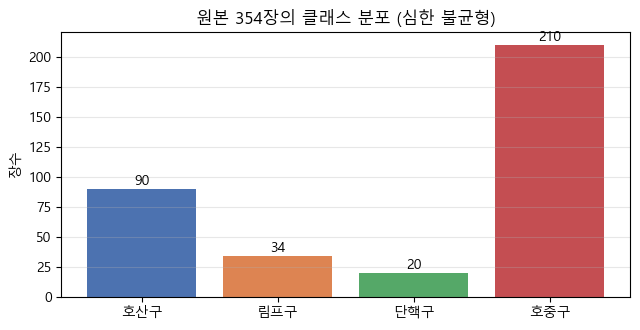

In [5]:
cnt = np.bincount(data['label'].values, minlength=NUM_CLASSES)
tbl = pd.DataFrame({'클래스': [f'{c}({KOR[c]})' for c in CLASS_NAMES],
                    '장수': cnt, '비율(%)': (cnt/cnt.sum()*100).round(1)})
display(tbl)

major = cnt.max()/cnt.sum()
print(f'불균형 비율 {cnt.max()/cnt.min():.1f}배')
print(f'무작위로 찍기        : 정확도 {1/NUM_CLASSES:.4f}')
print(f'★ 기준선 0 — 전부 {KOR[CLASS_NAMES[int(cnt.argmax())]]}로 찍기 : 정확도 {major:.4f}')
print('  ↑ 이 숫자를 못 넘으면 모델이 아무 일도 안 한 것이다.')
print('  ↑ 그리고 이때 macro-F1 은', f'{1/NUM_CLASSES*2*major/(major+1/NUM_CLASSES)*0 + (2*major/(1+major))/NUM_CLASSES:.4f}',
      '수준으로 매우 낮다 → 주지표를 macro-F1 으로 잡는 이유 (수업 4-5)')

plt.figure(figsize=(6.5, 3.4))
bars = plt.bar([KOR[c] for c in CLASS_NAMES], cnt, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
for b, v in zip(bars, cnt):
    plt.text(b.get_x()+b.get_width()/2, v+3, str(v), ha='center')
plt.title('원본 354장의 클래스 분포 (심한 불균형)'); plt.ylabel('장수')
plt.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

### 이 표가 정하는 것 두 가지

1. **주지표는 macro-F1 이다.** 호중구가 59%라 전부 호중구로 찍어도 정확도 0.59가 나온다.
   정확도는 **함께 보고하되 주지표가 아니다.** (수업 4-5 "정확도만으로 부족한 이유")
2. **클래스 가중치를 쓸 자리가 있다.** 단핵구는 21장, 호중구는 207장이다.
   수업 4-7 의 `pos_weight` 를 다중 클래스로 옮기면 `CrossEntropyLoss(weight=...)` 다.
   이게 베이스라인 3단의 마지막 계단이 된다.

---
# §4. 이미지를 눈으로 본다

**모델을 고르기 전에 데이터를 본다.**

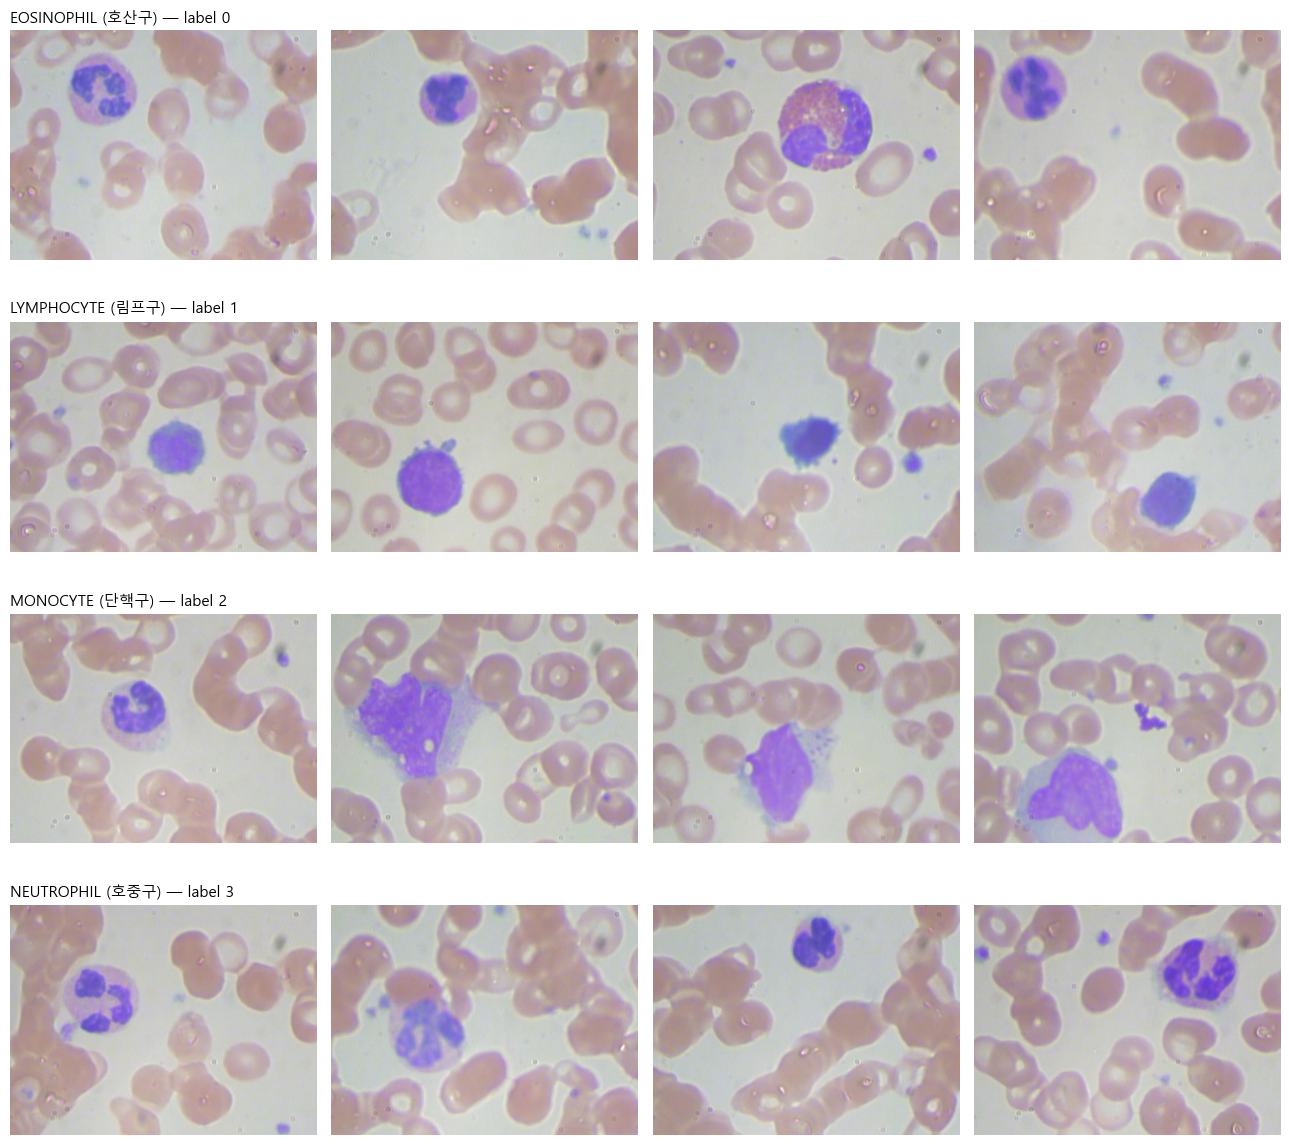

이미지 크기 (640, 480) | 모드 RGB | 총 354 장


In [6]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(13, 3.0*NUM_CLASSES))
rng = np.random.RandomState(0)
for r, c in enumerate(CLASS_NAMES):
    sub = data[data.category == c]
    for k, p in enumerate(rng.choice(sub['path'].values, min(4, len(sub)), replace=False)):
        axes[r, k].imshow(Image.open(p)); axes[r, k].axis('off')
    axes[r, 0].set_title(f'{c} ({KOR[c]}) — label {r}', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

im0 = Image.open(data.iloc[0]['path'])
print('이미지 크기', im0.size, '| 모드', im0.mode, '| 총', len(data), '장')

### 관찰

| 관찰 | 뒤에서 어떻게 쓰이나 |
|---|---|
| 화면의 대부분이 **분홍색 적혈구**이고, 판단 근거는 가운데 **진한 보라색 백혈구 한 개** | §17 CAM 에서 모델이 그걸 보는지 확인 |
| 클래스별 생김새: 호산구=핵 두 덩이+분홍 과립 / 림프구=작고 둥근 진한 핵 / 단핵구=콩팥 모양·가장 큼 / 호중구=3~5 덩이로 갈라짐 | **형태**가 핵심, **색**이 보조 → 색 증강은 약하게 |
| 세포 방향이 제각각 | 회전·반전 증강이 안전하다 |
| 모든 이미지가 **640×480** 으로 일정 | Resize 만 하면 된다 |

### 소벨 필터로 확인 — 합성곱이 무엇을 보는가

> **📘 영상처리 §2-9 엣지 검출**: 소벨 필터로 경계를 잡는 것을 배웠다.
> CNN 의 첫 층들이 학습하는 것이 대체로 이런 종류의 필터다.
> 우리 데이터에서 **핵의 경계**가 잡히면 CNN 이 이 문제에 적합하다는 근거가 된다.

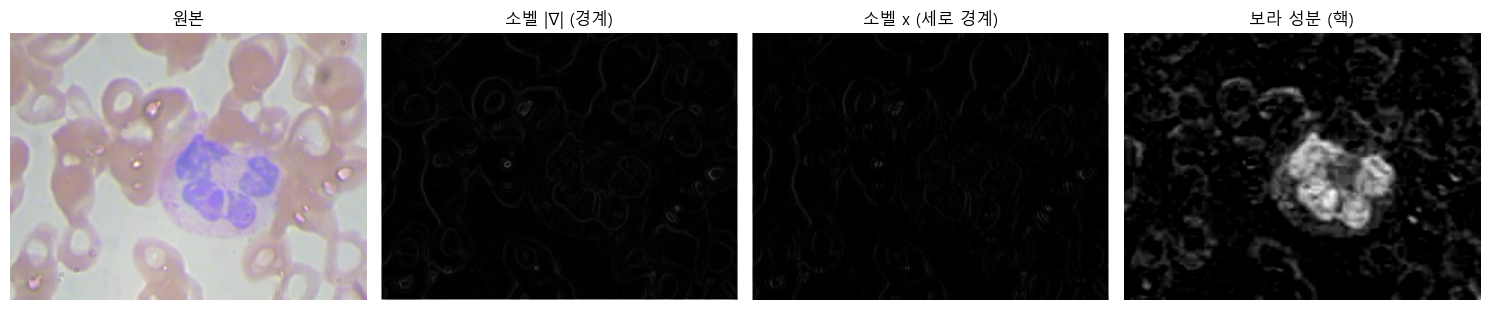

입력 (1, 1, 480, 640) → conv2d(3x3, padding=1) → (1, 1, 480, 640)
영상처리 출력 크기 공식: (입력 - 커널 + 2×패딩)/스트라이드 + 1 = (640 - 3 + 2)/1 + 1 = 640


In [7]:
sobel_x = torch.tensor([[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]]).view(1,1,3,3)
sobel_y = torch.tensor([[-1.,-2.,-1.],[0.,0.,0.],[1.,2.,1.]]).view(1,1,3,3)

g = torch.tensor(np.asarray(im0.convert('L'), np.float32)/255.)[None, None]
gx, gy = F.conv2d(g, sobel_x, padding=1), F.conv2d(g, sobel_y, padding=1)
mag = (gx**2 + gy**2).sqrt()[0,0]
arr = np.asarray(im0.convert('RGB'), np.float32)/255.
purple = np.clip(arr[...,2]-arr[...,1], 0, 1)          # 파랑-초록: 보라색 핵이 밝게 나온다

fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
for a, img, t in zip(ax, [np.asarray(im0), mag.numpy(), gx[0,0].abs().numpy(), purple],
                     ['원본', '소벨 |∇| (경계)', '소벨 x (세로 경계)', '보라 성분 (핵)']):
    a.imshow(img, cmap=None if t=='원본' else 'gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

print('입력', tuple(g.shape), '→ conv2d(3x3, padding=1) →', tuple(gx.shape))
print(f'영상처리 출력 크기 공식: (입력 - 커널 + 2×패딩)/스트라이드 + 1 = '
      f'({g.shape[-1]} - 3 + 2)/1 + 1 = {g.shape[-1]}')

---
# §5. 전처리와 증강

> **📘 수업 3-13 / 5-2**: 증강은 **학습용에만** 건다. **검증·시험 데이터는 증강하지 않는다.**
> (수업 5장에서 검증셋에 증강이 걸려 있던 버그를 지적했었다. 여기서는 고쳐 쓴다)
> 정규화 값은 **ImageNet 통계** — 사전학습 백본이 그 분포로 학습됐기 때문이다.
> `Normalize` 는 항상 `ToTensor` **뒤**에 온다.

혈액 도말은 **방향에 의미가 없으므로** 회전·반전이 안전하다
(수업 5장에서 X-ray 에 회전을 주지 않은 것과 반대의 판단이고, 이유는 같다 —
"실제로 존재할 수 있는 변형만 준다").

| 프리셋 | 내용 | 세운 가설 |
|---|---|---|
| `none` | Resize 만 | 기준선 |
| `flip` | 좌우·상하 반전 | 방향 무의미 → 도움 |
| `flip_rot` | + 회전 15° | 도말 각도는 무작위 → 도움 |
| `affine` | + 이동·확대 | 세포 위치·크기 변동 → 도움 |
| `color` | + 약한 색 변화 | 염색 색조가 신호 → **세게 주면 해로울 것** |

§12 에서 실험으로 판정한다.

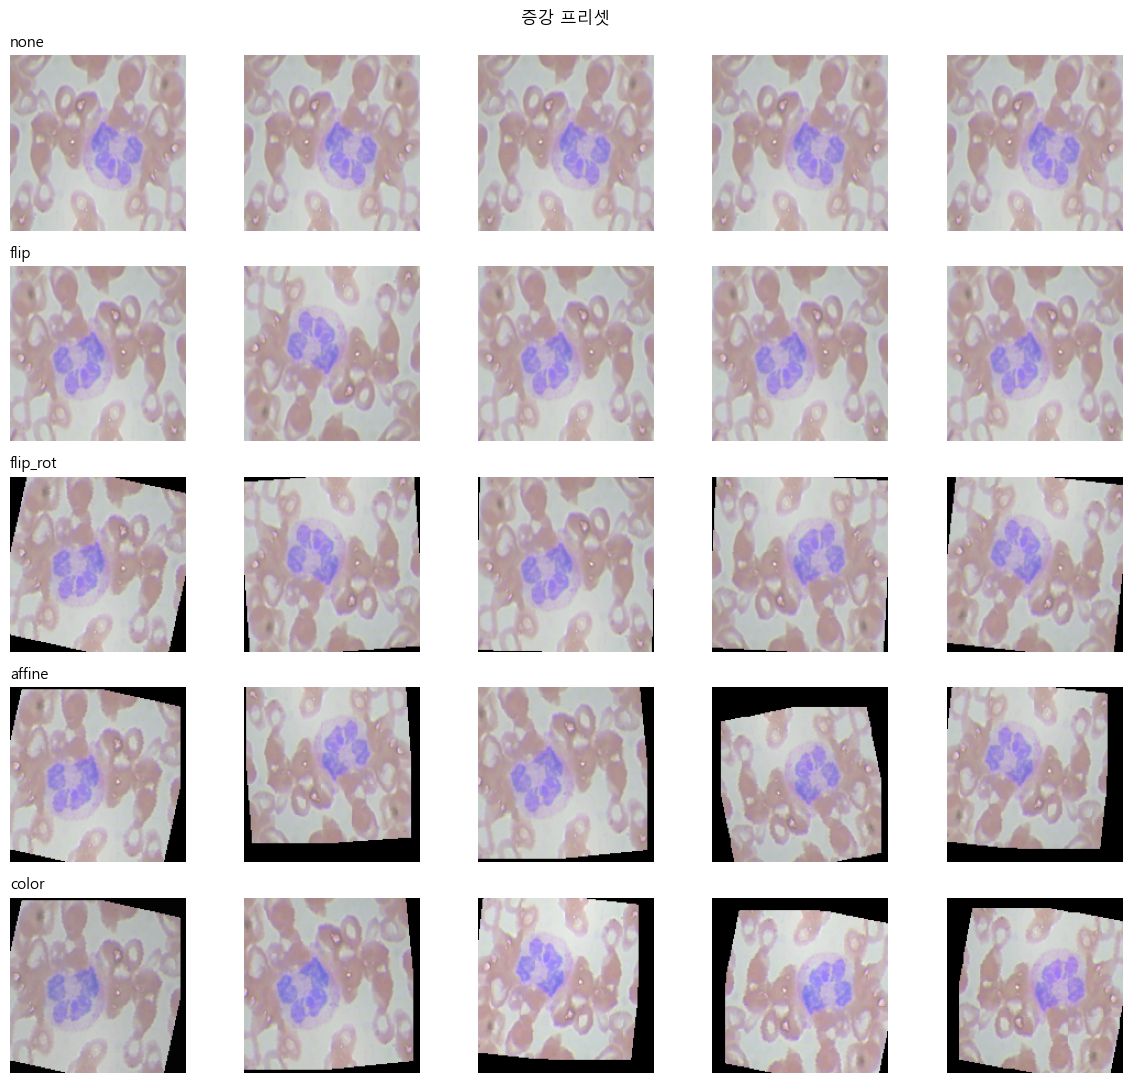

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

AUG_PRESETS = {
    'none'     : [],
    'flip'     : [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip()],
    'flip_rot' : [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                  transforms.RandomRotation(15)],
    'affine'   : [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                  transforms.RandomRotation(15),
                  transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1))],
    'color'    : [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                  transforms.RandomRotation(15),
                  transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
                  transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.02)],
}

def build_train_tf(preset, size=None):
    size = size or IMAGE_SIZE
    return transforms.Compose([transforms.Resize((size, size))] + AUG_PRESETS[preset] +
                              [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

def build_eval_tf(size=None):
    size = size or IMAGE_SIZE
    return transforms.Compose([transforms.Resize((size, size)), transforms.ToTensor(),
                               transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

def denorm(x):
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1); s = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (x.detach().cpu()*s + m).clamp(0,1).permute(1,2,0).numpy()

# 프리셋을 눈으로 확인 — 같은 프리셋인데 매번 달라야 정상이다(무작위 증강)
fig, axes = plt.subplots(len(AUG_PRESETS), 5, figsize=(12, 2.2*len(AUG_PRESETS)))
src = Image.open(data.iloc[0]['path']).convert('RGB')
for r, name in enumerate(AUG_PRESETS):
    tf_ = build_train_tf(name, 160); torch.manual_seed(0); random.seed(0)
    for k in range(5):
        axes[r, k].imshow(denorm(tf_(src))); axes[r, k].axis('off')
    axes[r, 0].set_title(name, loc='left', fontsize=11)
plt.suptitle('증강 프리셋'); plt.tight_layout(); plt.show()

---
# §6. 층화 3분할과 커스텀 Dataset

> **📘 수업 4-3**: `train_test_split` 은 한 번에 둘로만 나눈다. **두 번 써서 셋으로** 나눈다.
> **`stratify` 가 핵심이다.** 이걸 빼면 분할마다 불균형 비율이 달라진다.

```
전체 354장
   ├─ test  20% (71장)  ← §15 까지 열지 않는다
   └─ 나머지 80%
        ├─ train 80% (226장)
        └─ val   20% (57장)  ← 모델·하이퍼파라미터 선택은 전부 이걸로
```

**원본을 나누므로 형제 사진이 생길 수 없다 = 누수 0.**

In [9]:
def make_split(seed=SPLIT_SEED, test_size=0.2, val_size=0.2):
    paths = data['path'].values; labels = data['label'].values
    x_tv, x_te, y_tv, y_te = train_test_split(
        paths, labels, test_size=test_size, stratify=labels, random_state=seed)
    x_tr, x_va, y_tr, y_va = train_test_split(
        x_tv, y_tv, test_size=val_size, stratify=y_tv, random_state=seed)
    # 누수 점검 — 세 분할에 같은 파일이 있으면 안 된다 (3조 노트북의 점검 방식)
    s_tr, s_va, s_te = set(x_tr), set(x_va), set(x_te)
    assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te), '분할이 겹친다'
    return (x_tr, y_tr), (x_va, y_va), (x_te, y_te)

(tr_x, tr_y), (va_x, va_y), (te_x, te_y) = make_split(SPLIT_SEED)
print(f'train {len(tr_x)}장 / val {len(va_x)}장 / test {len(te_x)}장  (합 {len(tr_x)+len(va_x)+len(te_x)})')
print('경로 교집합 0 확인 완료')

dist = pd.DataFrame({'train': np.bincount(tr_y, minlength=4),
                     'val'  : np.bincount(va_y, minlength=4),
                     'test' : np.bincount(te_y, minlength=4)},
                    index=[f'{c}({KOR[c]})' for c in CLASS_NAMES])
display(dist)
print('※ 단핵구가 val 과 test 에 몇 장뿐인지 보라. 이 숫자가 작을수록 한 번의 결과를 믿으면 안 된다.')
print('   → 그래서 §15 에서 시드를 바꿔 5번 반복하고 평균 ± 표준편차로 보고한다.')

train 226장 / val 57장 / test 71장  (합 354)
경로 교집합 0 확인 완료


,train,val,test
EOSINOPHIL(호산구),57,15,18
LYMPHOCYTE(림프구),22,5,7
MONOCYTE(단핵구),13,3,4
NEUTROPHIL(호중구),134,34,42


※ 단핵구가 val 과 test 에 몇 장뿐인지 보라. 이 숫자가 작을수록 한 번의 결과를 믿으면 안 된다.
   → 그래서 §15 에서 시드를 바꿔 5번 반복하고 평균 ± 표준편차로 보고한다.


배치 모양 (16, 3, 224, 224) | 라벨 dtype torch.int64 | 예시 [1, 3, 3, 0, 0, 1, 3, 3]


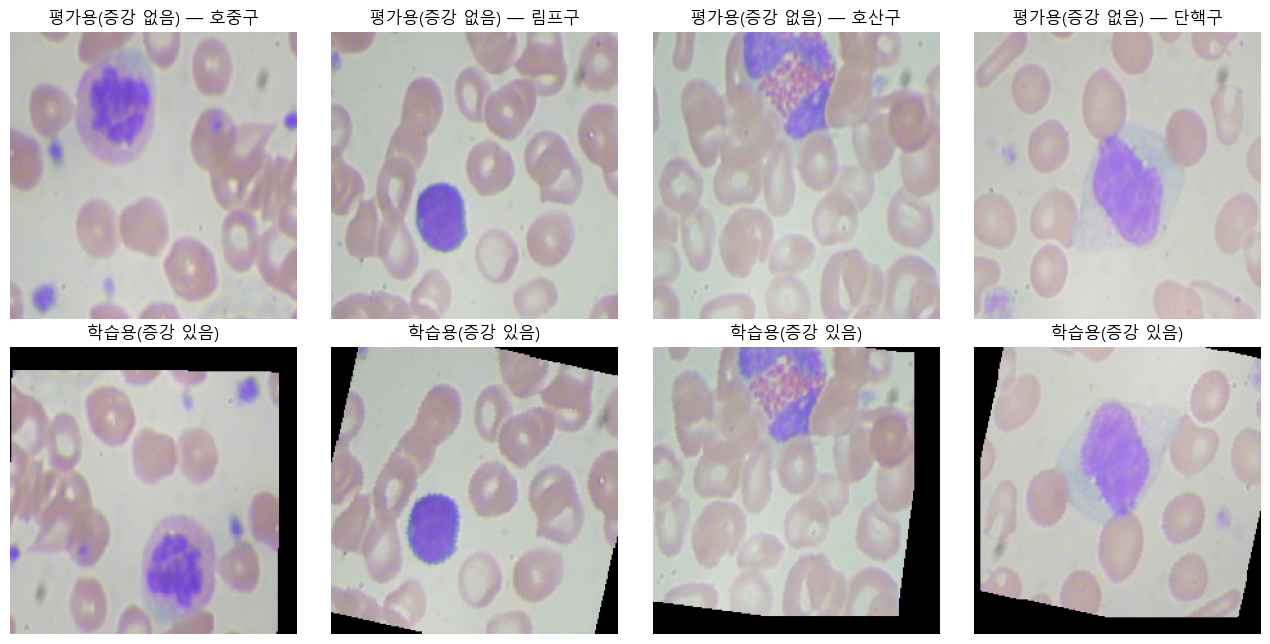

In [10]:
class BloodCellDataset(Dataset):
    """수업 4-3 의 커스텀 Dataset 골격.  __len__ 과 __getitem__ 두 개면 된다.
    라벨은 long(정수)으로 준다 — CrossEntropyLoss 가 정수 라벨을 받기 때문이다.
    (4·5장의 이진 분류에서는 float 으로 바꿔야 했다)"""
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.transform(img), torch.tensor(self.labels[i], dtype=torch.long)


def make_loaders(preset='flip', size=None, batch_size=None, split=None):
    (a_x, a_y), (b_x, b_y), (c_x, c_y) = split or ((tr_x, tr_y), (va_x, va_y), (te_x, te_y))
    bs = batch_size or BATCH_SIZE
    tr_tf, ev_tf = build_train_tf(preset, size), build_eval_tf(size)
    kw = dict(num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
    return (DataLoader(BloodCellDataset(a_x, a_y, tr_tf), batch_size=bs, shuffle=True, **kw),
            DataLoader(BloodCellDataset(b_x, b_y, ev_tf), batch_size=bs*2, shuffle=False, **kw),
            DataLoader(BloodCellDataset(c_x, c_y, ev_tf), batch_size=bs*2, shuffle=False, **kw))

L_tr, L_va, L_te = make_loaders('flip')
xb, yb = next(iter(L_tr))
print('배치 모양', tuple(xb.shape), '| 라벨 dtype', yb.dtype, '| 예시', yb[:8].tolist())

# 증강 있는 것 / 없는 것을 나란히 확인
fig, ax = plt.subplots(2, 4, figsize=(13, 6.5))
ds_aug = BloodCellDataset(tr_x, tr_y, build_train_tf('affine'))
ds_raw = BloodCellDataset(tr_x, tr_y, build_eval_tf())
for k in range(4):
    x0, y0 = ds_raw[k]; x1, _ = ds_aug[k]
    ax[0, k].imshow(denorm(x0)); ax[0, k].set_title(f'평가용(증강 없음) — {KOR[CLASS_NAMES[y0]]}'); ax[0, k].axis('off')
    ax[1, k].imshow(denorm(x1)); ax[1, k].set_title('학습용(증강 있음)'); ax[1, k].axis('off')
plt.tight_layout(); plt.show()

---
# §7. 모델 3종 — 수업 4장의 3단

> **📘 수업 2-3**: `nn.Module` 을 상속하고 `__init__` 에 층을, `forward` 에 흐름을 쓴다.
> **출력층에 softmax 를 붙이지 않는다** — `CrossEntropyLoss` 가 안에서 처리한다.

| | 수업 근거 | 무엇을 재는가 |
|---|---|---|
| **A. SimpleCNN** | **4-4 밑바닥 CNN — 기준선** (구조는 3-12 Conv-BN-ReLU-Pool) | 데이터만으로 얼마나 되나 |
| **B. 백본 고정** | **4-6 전이학습** | ImageNet 특징만으로 되나 |
| **C. 전체 미세조정** | **5-3** (+ **4-7** 클래스 가중치) | 본 게임 |

셋 다 **`특징맵 → GAP → Linear`** 로 끝난다. 이 구조여야 §17 의 CAM 을 뽑을 수 있다.

> `nn.ReLU(inplace=False)` 로 두는 이유: `inplace=True` 는 Grad-CAM 의 backward 후크와 충돌해
> `RuntimeError` 가 난다. 미리 막아 둔다.

In [11]:
class SimpleCNN(nn.Module):
    """A. 밑바닥 CNN — 수업 4-4 의 기준선 역할, 구조는 3-12"""
    def __init__(self, num_classes=NUM_CLASSES, width=32, use_bn=True, dropout=0.3):
        super().__init__()
        def block(i, o):
            layers = [nn.Conv2d(i, o, 3, padding=1)]
            if use_bn: layers.append(nn.BatchNorm2d(o))       # 수업 2-10 / 3-12
            layers += [nn.ReLU(inplace=False), nn.MaxPool2d(2)]
            return layers
        self.features = nn.Sequential(*block(3, width), *block(width, width*2),
                                      *block(width*2, width*4), *block(width*4, width*8))
        self.pool = nn.AdaptiveAvgPool2d(1)                   # GAP
        self.drop = nn.Dropout(dropout)                       # 수업 2-10
        self.head = nn.Linear(width*8, num_classes)           # 선형 한 층 → CAM 가능

    def forward_features(self, x): return self.features(x)
    def forward(self, x):
        return self.head(self.drop(self.pool(self.forward_features(x)).flatten(1)))


class TransferNet(nn.Module):
    """B(freeze=True) / C(freeze=False) — 수업 4-6, 5-3"""
    BUILDERS = {
        'efficientnet_v2_s': (models.efficientnet_v2_s, 'EfficientNet_V2_S_Weights'),
        'efficientnet_b0'  : (models.efficientnet_b0,   'EfficientNet_B0_Weights'),
        'resnet18'         : (models.resnet18,          'ResNet18_Weights'),
        'resnet34'         : (models.resnet34,          'ResNet34_Weights'),
    }
    def __init__(self, backbone='efficientnet_v2_s', num_classes=NUM_CLASSES,
                 pretrained=True, freeze=False, dropout=0.5, probe_size=224):
        super().__init__()
        fn, wname = self.BUILDERS[backbone]
        weights = getattr(models, wname).IMAGENET1K_V1 if pretrained else None
        net = fn(weights=weights)
        self.features = (nn.Sequential(*list(net.children())[:-2])
                         if backbone.startswith('resnet') else net.features)
        if freeze:                                   # 수업 4-6: 백본 고정 → 헤드만 학습
            for p in self.features.parameters():
                p.requires_grad = False
        with torch.no_grad():                        # 출력 채널 수는 더미 입력으로 확인 (5-3: 손으로 적지 않는다)
            n_feat = self.features(torch.zeros(1, 3, probe_size, probe_size)).shape[1]
        self.num_features = n_feat
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(n_feat, num_classes)

    def forward_features(self, x): return self.features(x)
    def forward(self, x):
        return self.head(self.drop(self.pool(self.forward_features(x)).flatten(1)))


def build_model(name='efficientnet_v2_s', pretrained=True, freeze=False,
                dropout=0.5, image_size=None):
    if name == 'simplecnn':
        return SimpleCNN(dropout=dropout)
    return TransferNet(name, pretrained=pretrained, freeze=freeze, dropout=dropout,
                       probe_size=image_size or IMAGE_SIZE)

def count_params(m):
    tot = sum(p.numel() for p in m.parameters())
    trn = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return tot, trn

In [12]:
# 수업 5-3 의 습관: 만들자마자 더미 입력을 흘려 shape 을 확인한다
print(f"{'모델':28s}{'특징맵':>18s}{'출력':>9s}{'전체 파라미터':>16s}{'학습 파라미터':>16s}")
for label, kw in [('A. SimpleCNN (밑바닥)',      dict(name='simplecnn', pretrained=False)),
                  ('B. EffNetV2-S 백본고정',     dict(name='efficientnet_v2_s', freeze=True)),
                  ('C. EffNetV2-S 미세조정',     dict(name='efficientnet_v2_s', freeze=False))]:
    nm = kw.pop('name')
    m = build_model(nm, image_size=IMAGE_SIZE, **kw)
    with torch.no_grad():
        f = m.forward_features(torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE))
        o = m(torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE))
    tot, trn = count_params(m)
    print(f'{label:28s}{str(tuple(f.shape)):>18s}{str(tuple(o.shape)):>9s}{tot:>16,}{trn:>16,}')
    del m

모델                                         특징맵       출력         전체 파라미터         학습 파라미터
A. SimpleCNN (밑바닥)            (1, 256, 14, 14)   (1, 4)         390,404         390,404
B. EffNetV2-S 백본고정             (1, 1280, 7, 7)   (1, 4)      20,182,612           5,124
C. EffNetV2-S 미세조정             (1, 1280, 7, 7)   (1, 4)      20,182,612      20,182,612


**수업 4-6 에서 "이 장에서 가장 인상적인 숫자"라고 한 것이 여기서도 나온다.**
백본을 고정하면 학습 파라미터가 **수천 개**로 줄어든다. 그만큼 빠르지만,
ImageNet 특징이 현미경 이미지에 맞지 않으면 성능이 따라오지 못한다. §10 에서 확인한다.

---
# §8. 학습 루프와 평가 함수

> **📘 수업 2-5 — 학습 루프 다섯 줄. 이 순서가 전부다.**
> ```python
> optimizer.zero_grad()               # 1. 이전 기울기 지우기
> output = model(data)                # 2. 순전파
> loss = criterion(output, target)    # 3. 손실 계산
> loss.backward()                     # 4. 역전파
> optimizer.step()                    # 5. 가중치 갱신
> ```
> **`zero_grad()` 를 빼면 기울기가 누적된다.** 파이토치에서 가장 많이 하는 실수다.
>
> **📘 수업 2-8 — 평가할 때 반드시 두 가지**: `model.eval()` + `torch.no_grad()`. 둘 다 필요하다.
>
> **📘 수업 2-1 정정**: 수업 `2.ipynb` 는 에폭마다 **마지막 배치의 손실**만 출력해 값이 들쭉날쭉했다.
> 여기서는 **에폭 평균**을 낸다.

## 이진 분류(4·5장) → 4클래스 다중 분류: 바뀌는 곳은 정확히 네 군데

| | 4·5장 (이진) | 이 프로젝트 (4클래스) |
|---|---|---|
| 출력층 | `nn.Linear(n, 1)` | **`nn.Linear(n, 4)`** |
| 손실 | `BCEWithLogitsLoss(pos_weight=)` | **`CrossEntropyLoss(weight=)`** |
| 로짓 → 확률 | `torch.sigmoid(logits)` | **`torch.softmax(logits, dim=1)`** |
| 확률 → 예측 | `probs > 0.5` | **`probs.argmax(1)`** (수업 2-8 의 `torch.max(output,1)` 과 같은 것) |
| 라벨 | `.float()` 필요 | **`long` 그대로** |
| 주지표 | AUC | **macro-F1** |

> **📘 수업 4-5 "확률과 예측을 나눠 담는 이유"**: 확률(`probs`)이 있어야 AUC 와 임계값 조정을 할 수 있고,
> 예측(`preds`)이 있어야 정확도·정밀도·재현율·혼동행렬을 계산할 수 있다. **둘 다 모은다.**

In [13]:
@torch.no_grad()                                     # ← 수업 2-8
def evaluate(model, loader, criterion=None):
    model.eval()                                     # ← 수업 2-8
    losses, L, T = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)                           # (B, 4) — squeeze 하지 않는다
        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))
        L.append(logits.float().cpu().numpy()); T.append(yb.cpu().numpy())

    logits = np.concatenate(L); trues = np.concatenate(T)
    probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()    # ← sigmoid 아님
    preds = probs.argmax(1)                                           # ← >0.5 아님
    try:
        auc = roc_auc_score(trues, probs, multi_class='ovr', average='macro')
    except ValueError:
        auc = float('nan')
    return {'loss': (sum(losses)/len(trues)) if criterion is not None else float('nan'),
            'accuracy'  : accuracy_score(trues, preds),
            'macro_f1'  : f1_score(trues, preds, average='macro', zero_division=0),
            'balanced'  : balanced_accuracy_score(trues, preds),
            'macro_prec': precision_score(trues, preds, average='macro', zero_division=0),
            'macro_rec' : recall_score(trues, preds, average='macro', zero_division=0),
            'recall_per_class': recall_score(trues, preds, average=None,
                                             labels=range(NUM_CLASSES), zero_division=0),
            'auc': auc, 'logits': logits, 'probs': probs, 'trues': trues, 'preds': preds}


def class_weights_from(labels):
    """수업 4-7 의 pos_weight 를 다중 클래스로 옮긴 것 — 적은 클래스에 큰 가중치"""
    cnt = np.bincount(np.asarray(labels), minlength=NUM_CLASSES).astype(np.float32)
    return len(labels) / (NUM_CLASSES * np.maximum(cnt, 1))

print('클래스 가중치 (train 기준):',
      dict(zip([KOR[c] for c in CLASS_NAMES], class_weights_from(tr_y).round(2))))

클래스 가중치 (train 기준): {'호산구': 0.99, '림프구': 2.57, '단핵구': 4.35, '호중구': 0.42}


In [14]:
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=0.0,
                class_weight=None, scheduler='plateau', patience=8,
                ckpt_path=f'{RESULT_DIR}/ckpt/tmp.pt', label='model', verbose=True):
    """수업 2-5 의 다섯 줄에 스케줄러·체크포인트·조기종료·시간 측정을 붙인 것.
    체크포인트와 조기종료 기준은 '검증 macro-F1' (불균형 다중분류의 주지표)"""
    model = model.to(device)
    w = None if class_weight is None else torch.tensor(class_weight, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=w)                       # 수업 4-7 의 가중치 자리
    params = [p for p in model.parameters() if p.requires_grad]     # 고정 백본이면 헤드만
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)   # 수업 2·4장 = Adam

    if scheduler == 'cosine':                                       # 수업 3-15 스케줄러 3종
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))
    elif scheduler == 'step':
        sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs//3), gamma=0.3)
    else:
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.3,
                                                           patience=3, min_lr=1e-7)
    hist = collections.defaultdict(list)
    best, best_epoch, bad = -np.inf, 0, 0

    for epoch in range(1, epochs + 1):
        model.train()                                               # ← 수업 2-8
        run_loss, run_correct, n = 0.0, 0, 0
        if device.type == 'cuda': torch.cuda.synchronize()          # ← 수업 1장
        t0 = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            # ===== 수업 2-5. 학습 루프 다섯 줄 =====
            optimizer.zero_grad()          # 1. 이전 기울기 지우기
            logits = model(xb)             # 2. 순전파
            loss = criterion(logits, yb)   # 3. 손실 계산
            loss.backward()                # 4. 역전파
            optimizer.step()               # 5. 가중치 갱신
            # =====================================
            run_loss += loss.item() * len(yb)                       # 에폭 평균을 내려고 누적
            run_correct += (logits.argmax(1) == yb).sum().item()
            n += len(yb)

        m = evaluate(model, val_loader, criterion)
        if device.type == 'cuda': torch.cuda.synchronize()
        sec = time.time() - t0
        sched.step(m['macro_f1']) if scheduler == 'plateau' else sched.step()

        hist['loss'].append(run_loss/n); hist['accuracy'].append(run_correct/n)
        hist['val_loss'].append(m['loss']); hist['val_acc'].append(m['accuracy'])
        hist['val_macro_f1'].append(m['macro_f1'])
        hist['lr'].append(optimizer.param_groups[0]['lr']); hist['sec'].append(sec)

        star = ''
        if m['macro_f1'] > best:
            best, best_epoch, bad = m['macro_f1'], epoch, 0
            torch.save(model.state_dict(), ckpt_path)               # ← 수업 2-6: state_dict 만
            star = '저장'
        else:
            bad += 1

        if verbose:
            over = ' ⚠3분초과' if sec > EPOCH_BUDGET else ''
            print(f'[{label}] {epoch:2d}/{epochs} loss {run_loss/n:.4f} acc {run_correct/n:.4f} '
                  f'| val_loss {m["loss"]:.4f} val_acc {m["accuracy"]:.4f} '
                  f'val_macroF1 {m["macro_f1"]:.4f} | lr {optimizer.param_groups[0]["lr"]:.1e} '
                  f'({sec:.1f}s){over} {star}')
        if bad >= patience:
            if verbose: print(f'  조기종료: {patience} 에폭 동안 개선 없음')
            break

    hist = dict(hist)
    hist.update(best_epoch=best_epoch, best_score=best, ckpt_path=ckpt_path,
                epoch_sec_mean=float(np.mean(hist['sec'])), epochs_run=len(hist['loss']))
    if verbose:
        print(f'best 검증 macro-F1 = {best:.4f} @epoch {best_epoch}')
        print(f'에폭당 평균 {hist["epoch_sec_mean"]:.1f}초 (예산 {EPOCH_BUDGET}초) '
              f'| 총 {hist["epochs_run"]}에폭 {sum(hist["sec"])/60:.1f}분')
    return hist

In [15]:
RUNS_CSV = f'{RESULT_DIR}/runs.csv'
if os.path.exists(RUNS_CSV):
    print(f'⚠ runs.csv 에 이미 {len(pd.read_csv(RUNS_CSV, encoding="utf-8-sig"))}건이 있다. '
          '다른 버전으로 돌린 기록이면 results/ 폴더를 지우고 시작하는 것이 안전하다.')

def already_run(run_id):
    if not os.path.exists(RUNS_CSV): return False
    with open(RUNS_CSV, newline='', encoding='utf-8-sig') as f:
        return any(r.get('run_id') == run_id for r in csv.DictReader(f))

def log_run(run_id, params, m_val, hist=None):
    row = dict(run_id=run_id, **params)
    for k in ['accuracy','macro_f1','balanced','macro_prec','macro_rec','auc','loss']:
        row[f'val_{k}'] = round(float(m_val[k]), 5)
    for i, c in enumerate(CLASS_NAMES):
        row[f'val_recall_{KOR[c]}'] = round(float(m_val['recall_per_class'][i]), 4)
    if hist:
        row.update(best_epoch=hist['best_epoch'], epochs_run=hist['epochs_run'],
                   epoch_sec=round(hist['epoch_sec_mean'], 2))
    old = []
    if os.path.exists(RUNS_CSV):
        with open(RUNS_CSV, newline='', encoding='utf-8-sig') as f: old = list(csv.DictReader(f))
    keys = sorted(set().union(*[set(r) for r in old + [row]])) if old else list(row)
    with open(RUNS_CSV, 'w', newline='', encoding='utf-8-sig') as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for r in old + [row]: w.writerow(r)
    return row

def runs_table():
    return pd.read_csv(RUNS_CSV, encoding='utf-8-sig') if os.path.exists(RUNS_CSV) else pd.DataFrame()

def summarize(m, name=''):
    return (f"{name:26s} acc {m['accuracy']:.4f}  macroF1 {m['macro_f1']:.4f}  "
            f"balanced {m['balanced']:.4f}  AUC {m['auc']:.4f}")


def run_experiment(run_id, model_name='efficientnet_v2_s', preset='flip', lr=1e-4,
                   epochs=None, freeze=False, pretrained=True, dropout=0.5, weight_decay=0.0,
                   scheduler='plateau', use_class_weight=False, patience=8, size=None,
                   batch_size=None, force=False, verbose=True):
    """실험 한 건. 조기종료·체크포인트·기록 기준은 전부 '검증셋'. test 는 건드리지 않는다."""
    if already_run(run_id) and not force:
        if verbose: print(f'[건너뜀] {run_id} — 이미 runs.csv 에 있음')
        return None
    epochs = epochs or SCREEN_EPOCHS
    set_seed(SPLIT_SEED)
    l_tr, l_va, _ = make_loaders(preset, size, batch_size)
    model = build_model(model_name, pretrained=pretrained, freeze=freeze,
                        dropout=dropout, image_size=size or IMAGE_SIZE)
    tot, trn = count_params(model)
    cw = class_weights_from(tr_y) if use_class_weight else None
    if verbose:
        print(f'=== {run_id} | {model_name} | 증강 {preset} | lr {lr:g} | '
              f'가중치 {bool(use_class_weight)} | 학습 파라미터 {trn:,}/{tot:,}')
    hist = train_model(model, l_tr, l_va, epochs=epochs, lr=lr, weight_decay=weight_decay,
                       class_weight=cw, scheduler=scheduler, patience=patience,
                       ckpt_path=f'{RESULT_DIR}/ckpt/{run_id}.pt', label=run_id, verbose=verbose)
    model.load_state_dict(torch.load(hist['ckpt_path'], map_location=device))
    m_val = evaluate(model, l_va, nn.CrossEntropyLoss())
    log_run(run_id, dict(model=model_name, preset=preset, lr=lr, freeze=int(freeze),
                         dropout=dropout, weight_decay=weight_decay, scheduler=scheduler,
                         class_weight=int(use_class_weight), image_size=size or IMAGE_SIZE,
                         params_M=round(tot/1e6, 2)), m_val, hist)
    if verbose: print(summarize(m_val, '  검증셋'))
    return dict(model=model, history=hist, val=m_val)

In [16]:
def plot_history(hist, title=''):
    fig, ax = plt.subplots(1, 4, figsize=(17, 3.2))
    e = range(1, len(hist['loss'])+1)
    ax[0].plot(e, hist['loss'], marker='o', label='학습'); ax[0].plot(e, hist['val_loss'], marker='o', label='검증')
    ax[0].set_title(f'{title} 손실'); ax[0].legend()
    ax[1].plot(e, hist['accuracy'], marker='o', label='학습'); ax[1].plot(e, hist['val_acc'], marker='o', label='검증')
    ax[1].set_title('정확도'); ax[1].legend()
    ax[2].plot(e, hist['val_macro_f1'], marker='o', color='tab:green'); ax[2].set_title('검증 macro-F1')
    ax[3].plot(e, hist['lr'], marker='o', color='tab:red'); ax[3].set_yscale('log'); ax[3].set_title('학습률')
    for a in ax: a.set_xlabel('epoch'); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()

def plot_confusion(y_true, y_pred, normalize=False, title='혼동행렬'):
    """수업 2-8 혼동행렬. 5장에서 지적된 '정규화를 imshow 앞으로' 를 반영했다"""
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
    shown = cm.astype(float)/np.maximum(cm.sum(1, keepdims=True), 1) if normalize else cm
    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    im_ = ax.imshow(shown, cmap='Blues'); fig.colorbar(im_, ax=ax); ax.set_title(title)
    t = np.arange(NUM_CLASSES)
    ax.set_xticks(t); ax.set_xticklabels([KOR[c] for c in CLASS_NAMES], rotation=25, ha='right')
    ax.set_yticks(t); ax.set_yticklabels([KOR[c] for c in CLASS_NAMES])
    thr = shown.max()/2
    for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
        ax.text(j, i, f'{shown[i,j]:.2f}' if normalize else f'{cm[i,j]}',
                ha='center', color='white' if shown[i,j] > thr else 'black')
    ax.set_ylabel('실제'); ax.set_xlabel('예측'); plt.tight_layout(); plt.show()
    return cm

---
# §9. 속도 프로브 — "1 에폭 최대 3분"

**모델을 고르기 전에 시간을 먼저 잰다.**

> **📘 수업 1장**: GPU 는 비동기라 `torch.cuda.synchronize()` 없이 재면 실제보다 빠르게 나온다.

원본 354장 중 학습은 226장이라 수업 5장(4,173장, 200초/에폭)보다 훨씬 가볍다.
그래도 조건을 확인하고 넘어간다.

,이름,params_M,img_per_sec,est_epoch_sec,판정
0,simplecnn,0.39,759.7,0.4,○ 3분 이내
1,resnet18,11.18,637.7,0.5,○ 3분 이내
2,efficientnet_b0,4.01,397.7,0.7,○ 3분 이내
3,efficientnet_v2_s (고정),20.18,648.5,0.5,○ 3분 이내
4,efficientnet_v2_s,20.18,171.3,1.7,○ 3분 이내


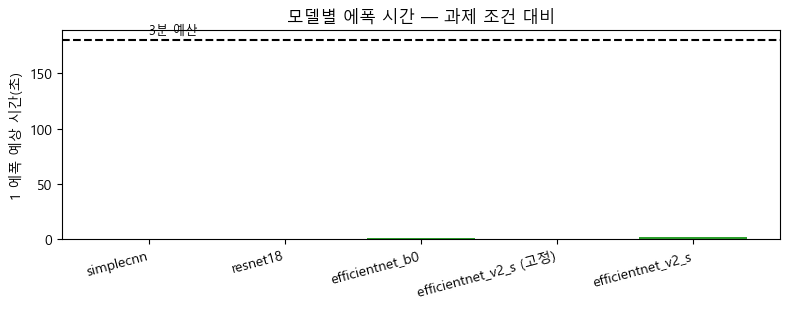

In [17]:
def speed_probe(model_name, freeze=False, batch_size=None, n_batches=6, n_train=None):
    set_seed(0)
    bs = batch_size or BATCH_SIZE
    n_train = n_train or len(tr_x)
    model = build_model(model_name, pretrained=False, freeze=freeze, image_size=IMAGE_SIZE).to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)
    crit = nn.CrossEntropyLoss()
    x = torch.randn(bs, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    y = torch.randint(0, NUM_CLASSES, (bs,), device=device)
    model.train()
    for i in range(n_batches + 3):
        if i == 3:
            if device.type == 'cuda': torch.cuda.synchronize()
            t0 = time.time()
        opt.zero_grad(); crit(model(x), y).backward(); opt.step()
    if device.type == 'cuda': torch.cuda.synchronize()
    dt = time.time() - t0
    ips = n_batches * bs / dt
    est = n_train / ips * 1.3                      # 검증·데이터로딩 몫 30% 가산
    tot, _ = count_params(model)
    del model, opt
    if device.type == 'cuda': torch.cuda.empty_cache()
    return dict(model=model_name, freeze=freeze, params_M=round(tot/1e6, 2),
                img_per_sec=round(ips, 1), est_epoch_sec=round(est, 1), fits=est <= EPOCH_BUDGET)

rows = [speed_probe(nm, freeze=fz) for nm, fz in
        [('simplecnn', False), ('resnet18', False), ('efficientnet_b0', False),
         ('efficientnet_v2_s', True), ('efficientnet_v2_s', False)]]
probe = pd.DataFrame(rows)
probe['이름'] = probe['model'] + np.where(probe['freeze'], ' (고정)', '')
probe['판정'] = np.where(probe['fits'], '○ 3분 이내', '✗ 초과')
display(probe[['이름', 'params_M', 'img_per_sec', 'est_epoch_sec', '판정']])

plt.figure(figsize=(8, 3.2))
plt.bar(probe['이름'], probe['est_epoch_sec'],
        color=['tab:green' if f else 'tab:red' for f in probe['fits']])
plt.axhline(EPOCH_BUDGET, ls='--', c='k'); plt.text(0, EPOCH_BUDGET*1.03, '3분 예산', fontsize=9)
plt.ylabel('1 에폭 예상 시간(초)'); plt.title('모델별 에폭 시간 — 과제 조건 대비')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

---
# §10. 실험 1 — 베이스라인 3단 비교  🔁 *여기서부터 에폭을 돌린다*

**수업 4장의 결론 구조를 그대로 재현한다.** 4장은 "세 모델 비교"로 끝났다.

| | 무엇을 재는가 |
|---|---|
| 기준선 0 — 전부 호중구로 찍기 | 아무 일도 안 했을 때의 점수 |
| **A. 밑바닥 CNN** (4-4) | 데이터만으로 |
| **B. 백본 고정** (4-6) | ImageNet 특징만으로 |
| **C. 미세조정** (5-3) | 백본까지 학습하면 |
| **C+. 미세조정 + 클래스 가중치** (4-7) | 소수 클래스를 살리면 |

A→C 가 **전이학습의 이득**, B→C 가 **"ImageNet 특징만으로는 부족하다"의 크기**,
C→C+ 가 **불균형 대응의 이득**이다.

In [18]:
BASE = [
    ('A_밑바닥CNN',        dict(model_name='simplecnn', pretrained=False, lr=1e-3, dropout=0.3)),
    ('B_백본고정',          dict(model_name='efficientnet_v2_s', freeze=True,  lr=1e-3, dropout=0.5)),
    ('C_미세조정',          dict(model_name='efficientnet_v2_s', freeze=False, lr=1e-4, dropout=0.5)),
    ('C+_미세조정_가중치',   dict(model_name='efficientnet_v2_s', freeze=False, lr=1e-4, dropout=0.5,
                              use_class_weight=True)),
]
base_res = {}
for rid, kw in BASE:
    r = run_experiment(rid, preset='flip', epochs=FULL_EPOCHS, patience=10, **kw)
    if r: base_res[rid] = r
    print('-' * 92)

=== A_밑바닥CNN | simplecnn | 증강 flip | lr 0.001 | 가중치 False | 학습 파라미터 390,404/390,404
[A_밑바닥CNN]  1/40 loss 1.0564 acc 0.5442 | val_loss 1.4465 val_acc 0.0877 val_macroF1 0.0403 | lr 1.0e-03 (2.3s) 저장
[A_밑바닥CNN]  2/40 loss 0.9835 acc 0.5973 | val_loss 1.0646 val_acc 0.5965 val_macroF1 0.1868 | lr 1.0e-03 (1.4s) 저장
[A_밑바닥CNN]  3/40 loss 0.9038 acc 0.6106 | val_loss 0.9572 val_acc 0.6316 val_macroF1 0.4003 | lr 1.0e-03 (1.3s) 저장
[A_밑바닥CNN]  4/40 loss 0.8363 acc 0.6814 | val_loss 1.9598 val_acc 0.5965 val_macroF1 0.1868 | lr 1.0e-03 (1.3s) 
[A_밑바닥CNN]  5/40 loss 0.7801 acc 0.7080 | val_loss 1.0189 val_acc 0.5263 val_macroF1 0.3418 | lr 1.0e-03 (1.2s) 
[A_밑바닥CNN]  6/40 loss 0.7195 acc 0.7124 | val_loss 1.4104 val_acc 0.5965 val_macroF1 0.1868 | lr 1.0e-03 (1.3s) 
[A_밑바닥CNN]  7/40 loss 0.6752 acc 0.7434 | val_loss 0.9945 val_acc 0.4912 val_macroF1 0.2465 | lr 3.0e-04 (1.3s) 
[A_밑바닥CNN]  8/40 loss 0.6534 acc 0.7212 | val_loss 0.6937 val_acc 0.6316 val_macroF1 0.3121 | lr 3.0e-04 (1.3s) 
[A_밑바닥

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


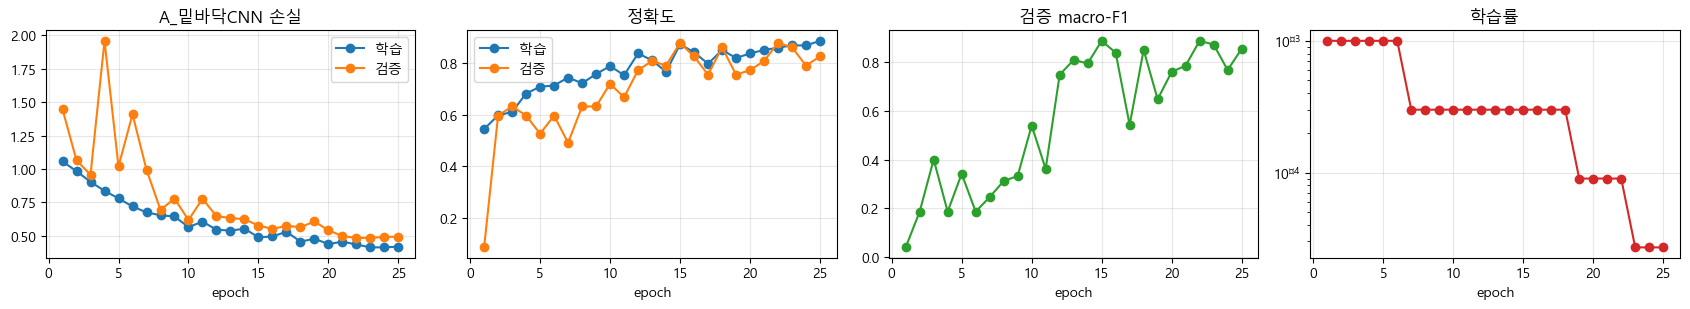

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


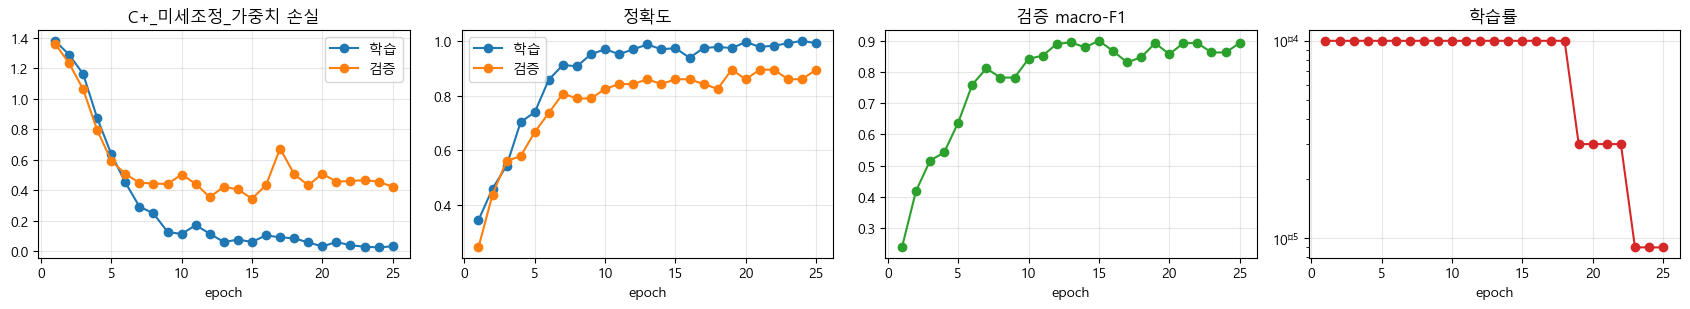

In [19]:
for rid in ['A_밑바닥CNN', 'C+_미세조정_가중치']:
    if rid in base_res: plot_history(base_res[rid]['history'], rid)

,run_id,params_M,best_epoch,epoch_sec,val_accuracy,val_macro_f1,val_auc,val_recall_호산구,val_recall_림프구,val_recall_단핵구,val_recall_호중구
0,A_밑바닥CNN,0.39,15,1.33,0.8772,0.8866,0.9400,0.6667,0.8,1.0000,0.9706
1,B_백본고정,20.18,27,1.59,0.5965,0.5044,0.7130,0.3333,0.4,0.3333,0.7647
2,C_미세조정,20.18,11,2.51,0.8772,0.9006,0.9332,0.5333,1.0,1.0000,1.0000
3,C+_미세조정_가중치,20.18,15,2.49,0.8596,0.9000,0.9658,0.6667,1.0,1.0000,0.9118


기준선 0 (전부 호중구) : 정확도 0.5932
무작위로 찍기                    : 정확도 0.2500


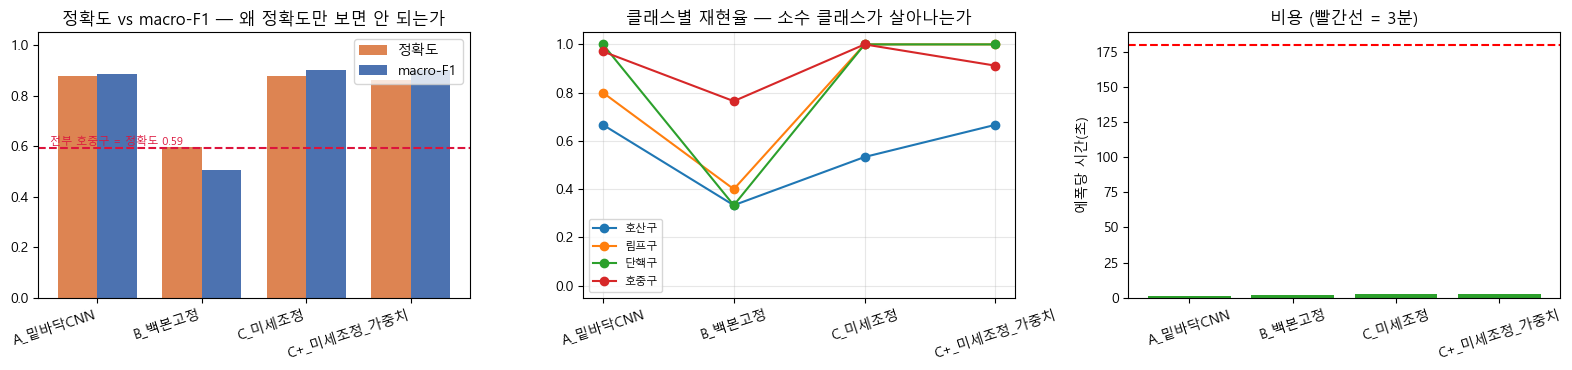

In [20]:
t = runs_table()
order = [r for r, _ in BASE]
b = t[t.run_id.isin(order)].set_index('run_id').reindex(order).reset_index()

show = ['run_id','params_M','best_epoch','epoch_sec','val_accuracy','val_macro_f1','val_auc'] + \
       [f'val_recall_{KOR[c]}' for c in CLASS_NAMES]
display(b[show].round(4))

print(f'기준선 0 (전부 {KOR[CLASS_NAMES[int(cnt.argmax())]]}) : 정확도 {major:.4f}')
print(f'무작위로 찍기                    : 정확도 {1/NUM_CLASSES:.4f}')

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
x = np.arange(len(b)); w = 0.38
ax[0].bar(x-w/2, b.val_accuracy, w, label='정확도', color='#DD8452')
ax[0].bar(x+w/2, b.val_macro_f1, w, label='macro-F1', color='#4C72B0')
ax[0].axhline(major, ls='--', c='crimson')
ax[0].text(-0.45, major+0.01, f'전부 호중구 = 정확도 {major:.2f}', color='crimson', fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(b.run_id, rotation=18, ha='right')
ax[0].set_title('정확도 vs macro-F1 — 왜 정확도만 보면 안 되는가'); ax[0].legend(); ax[0].set_ylim(0, 1.05)

for i, c in enumerate(CLASS_NAMES):
    ax[1].plot(b.run_id, b[f'val_recall_{KOR[c]}'], marker='o', label=KOR[c])
ax[1].set_title('클래스별 재현율 — 소수 클래스가 살아나는가'); ax[1].legend(fontsize=8)
ax[1].tick_params(axis='x', rotation=18); ax[1].set_ylim(-0.05, 1.05); ax[1].grid(alpha=.3)

ax[2].bar(b.run_id, b.epoch_sec, color='tab:green'); ax[2].axhline(EPOCH_BUDGET, ls='--', c='r')
ax[2].set_ylabel('에폭당 시간(초)'); ax[2].set_title('비용 (빨간선 = 3분)')
ax[2].tick_params(axis='x', rotation=18)
plt.tight_layout(); plt.show()

### 읽는 법 — 이 표가 보고서의 뼈대다

1. **정확도와 macro-F1 을 나란히 본다.** 정확도가 0.6인데 macro-F1 이 0.3이면
   **소수 클래스를 통째로 놓치고 다수 클래스만 맞힌 것**이다 (수업 4-5 의 핵심).
2. **가운데 그래프의 단핵구·림프구 선**을 본다. 클래스 가중치를 넣었을 때 올라가면
   수업 4-7 의 처방이 여기서도 통한 것이다.
3. **B(고정) 가 C(미세조정) 에 크게 못 미치면** — 현미경 이미지가 ImageNet 과 결이 다르다는 뜻이고,
   수업 5-3 의 "도메인이 다르면 미세조정" 원칙과 일치한다.

> 이 차이들이 **통계적으로 유의한지**는 §19 에서 확인한다. 지금은 "숫자가 다르다"까지만 말한다.

---
# §11. 실험 2 — 에폭을 몇으로 잡을 것인가  🔁

"충분한 에폭"은 감이 아니라 **곡선으로** 정한다. 여기서는 **조기종료를 끄고** 끝까지 돌려
과적합이 시작되는 지점을 눈으로 확인한다.

> **📘 수업 2-9 / 5-4**: 학습 손실은 계속 내려가는데 **검증 손실이 오르기 시작하면 외우기 시작한 것**이다.
> 데이터가 226장뿐이라 이 현상이 아주 빨리 나타난다.

In [21]:
set_seed(SPLIT_SEED)
l_tr, l_va, _ = make_loaders('flip')
LONG = max(FULL_EPOCHS, 20)
long_model = build_model('simplecnn', pretrained=False, dropout=0.3)
hist_long = train_model(long_model, l_tr, l_va, epochs=LONG, lr=1e-3,
                        patience=LONG,                    # 조기종료 사실상 끔
                        ckpt_path=f'{RESULT_DIR}/ckpt/epoch_study.pt', label='에폭탐색',
                        verbose=False)
print(f'총 {hist_long["epochs_run"]}에폭, 에폭당 {hist_long["epoch_sec_mean"]:.1f}초')

총 40에폭, 에폭당 1.3초


C:\Users\KDS23\AppData\Local\Temp\ipykernel_26896\968391991.py:15: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


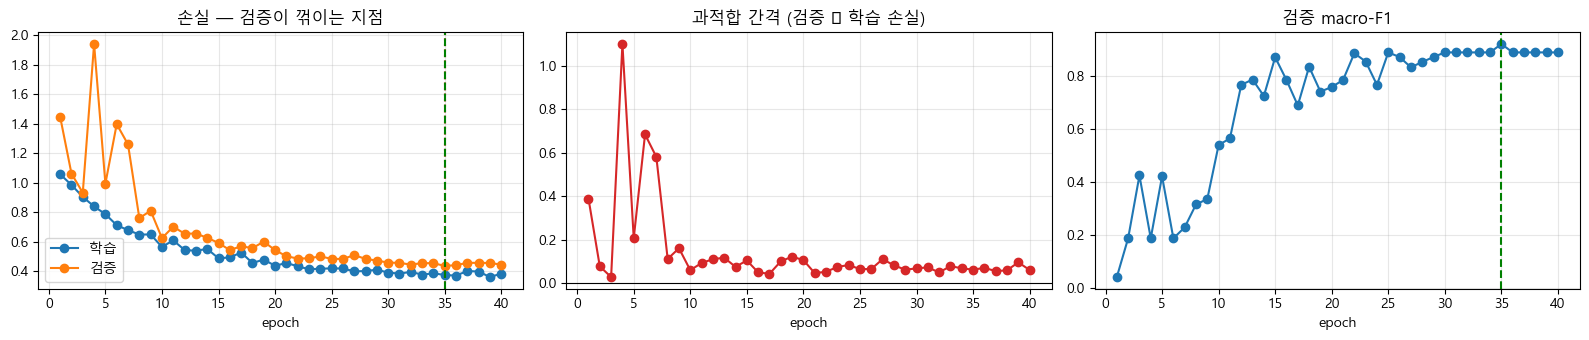

검증 손실 최저     : epoch 35
검증 macro-F1 최고 : epoch 35
3분 예산 대비 여유 : 141배

결론: best_epoch 가 최대 에폭에 붙어 있으면 덜 학습된 것이니 FULL_EPOCHS 를 늘린다.
      한참 앞에서 멈췄으면 그 값이 "충분한 에폭"이고, patience 는 그 뒤 몇 에폭을 기다릴지다.


In [22]:
e = np.arange(1, len(hist_long['loss'])+1)
gap = np.array(hist_long['val_loss']) - np.array(hist_long['loss'])
best_e = hist_long['best_epoch']; min_loss_e = int(np.argmin(hist_long['val_loss']))+1

fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
ax[0].plot(e, hist_long['loss'], marker='o', label='학습')
ax[0].plot(e, hist_long['val_loss'], marker='o', label='검증')
ax[0].axvline(min_loss_e, ls=':', c='r'); ax[0].axvline(best_e, ls='--', c='g')
ax[0].set_title('손실 — 검증이 꺾이는 지점'); ax[0].legend()
ax[1].plot(e, gap, marker='o', color='tab:red'); ax[1].axhline(0, c='k', lw=.8)
ax[1].set_title('과적합 간격 (검증 − 학습 손실)')
ax[2].plot(e, hist_long['val_macro_f1'], marker='o', color='tab:blue')
ax[2].axvline(best_e, ls='--', c='g'); ax[2].set_title('검증 macro-F1')
for a in ax: a.set_xlabel('epoch'); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'검증 손실 최저     : epoch {min_loss_e}')
print(f'검증 macro-F1 최고 : epoch {best_e}')
print(f'3분 예산 대비 여유 : {EPOCH_BUDGET/max(hist_long["epoch_sec_mean"],1e-9):.0f}배')
print()
print('결론: best_epoch 가 최대 에폭에 붙어 있으면 덜 학습된 것이니 FULL_EPOCHS 를 늘린다.')
print('      한참 앞에서 멈췄으면 그 값이 "충분한 에폭"이고, patience 는 그 뒤 몇 에폭을 기다릴지다.')

---
# §12. 실험 3 — 증강 비교  🔁

**조건을 하나만 바꾼다** — 모델·학습률·에폭·시드를 고정하고 증강만 바꾼다.
판단은 **검증셋으로만** 한다. test 는 아직 열지 않는다.

=== AUG_none | efficientnet_v2_s | 증강 none | lr 0.0001 | 가중치 True | 학습 파라미터 20,182,612/20,182,612
[AUG_none]  1/15 loss 1.4148 acc 0.2522 | val_loss 1.3730 val_acc 0.2632 val_macroF1 0.2280 | lr 1.0e-04 (2.4s) 저장
[AUG_none]  2/15 loss 1.2475 acc 0.4823 | val_loss 1.2703 val_acc 0.5263 val_macroF1 0.4240 | lr 1.0e-04 (2.5s) 저장
[AUG_none]  3/15 loss 1.0756 acc 0.5973 | val_loss 1.1408 val_acc 0.4912 val_macroF1 0.4134 | lr 1.0e-04 (2.5s) 
[AUG_none]  4/15 loss 0.8242 acc 0.7345 | val_loss 0.9161 val_acc 0.5263 val_macroF1 0.4573 | lr 1.0e-04 (2.5s) 저장
[AUG_none]  5/15 loss 0.5909 acc 0.8628 | val_loss 0.7263 val_acc 0.7018 val_macroF1 0.6933 | lr 1.0e-04 (2.5s) 저장
[AUG_none]  6/15 loss 0.3625 acc 0.9071 | val_loss 0.6282 val_acc 0.7719 val_macroF1 0.7506 | lr 1.0e-04 (2.5s) 저장
[AUG_none]  7/15 loss 0.2730 acc 0.9204 | val_loss 0.5811 val_acc 0.7895 val_macroF1 0.7905 | lr 1.0e-04 (2.5s) 저장
[AUG_none]  8/15 loss 0.1958 acc 0.9469 | val_loss 0.5367 val_acc 0.7895 val_macroF1 0.8096 | lr 1.

,증강,val_macro_f1,val_accuracy,best_epoch,epoch_sec,val_recall_호산구,val_recall_림프구,val_recall_단핵구,val_recall_호중구
6,flip_rot,0.9143,0.8772,10,2.53,0.7333,1.0,1.0,0.9118
8,color,0.9143,0.8772,11,3.01,0.7333,1.0,1.0,0.9118
7,affine,0.9105,0.8772,10,2.54,0.6667,1.0,1.0,0.9412
4,none,0.9006,0.8772,13,2.47,0.5333,1.0,1.0,1.0000
5,flip,0.8896,0.8596,14,2.48,0.5333,1.0,1.0,0.9706


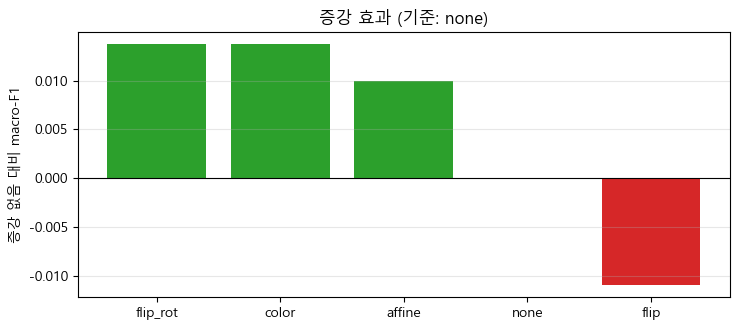

선정된 증강: flip_rot


In [23]:
REF = dict(model_name='efficientnet_v2_s', lr=1e-4, dropout=0.5, use_class_weight=True)
for p in AUG_PRESETS:
    run_experiment(f'AUG_{p}', preset=p, epochs=SCREEN_EPOCHS, patience=8, **REF)
    print('-' * 92)

t = runs_table(); a = t[t.run_id.str.startswith('AUG_')].copy()
a['증강'] = a.run_id.str[4:]
a = a.sort_values('val_macro_f1', ascending=False)
display(a[['증강','val_macro_f1','val_accuracy','best_epoch','epoch_sec'] +
          [f'val_recall_{KOR[c]}' for c in CLASS_NAMES]].round(4))

base_none = float(a[a['증강']=='none'].val_macro_f1.iloc[0])
d = a.val_macro_f1 - base_none
plt.figure(figsize=(7.5, 3.4))
plt.bar(a['증강'], d, color=['tab:green' if v>0 else 'tab:red' for v in d])
plt.axhline(0, c='k', lw=.8); plt.ylabel('증강 없음 대비 macro-F1')
plt.title('증강 효과 (기준: none)'); plt.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

BEST_PRESET = str(a.iloc[0]['증강'])
print('선정된 증강:', BEST_PRESET)

### 가설이 맞았는지 확인한다

| §5 에서 세운 가설 | 확인 방법 |
|---|---|
| 방향에 의미가 없으니 반전이 도움 | `flip` 이 `none` 보다 높으면 지지 |
| 도말 각도가 무작위이니 회전도 도움 | `flip_rot` 이 `flip` 보다 높으면 지지 |
| 염색 색조가 클래스 신호이니 색 증강은 해로울 수 있음 | `color` 가 `affine` 보다 낮으면 지지 |

**예상이 빗나갔다면 그것도 결과다.** 왜 빗나갔는지 쓰는 게 더 좋은 보고서다.
데이터가 226장뿐이라 증강 하나하나의 차이가 크게 나타나는 것이 정상이다.

---
# §13. 실험 4 — 하이퍼파라미터  🔁

**한 번에 하나씩** 바꾼다. 전부 검증셋으로만 판단한다.

=== LR_0.0003 | efficientnet_v2_s | 증강 flip_rot | lr 0.0003 | 가중치 True | 학습 파라미터 20,182,612/20,182,612
[LR_0.0003]  1/15 loss 1.3824 acc 0.3274 | val_loss 1.3445 val_acc 0.5614 val_macroF1 0.2368 | lr 3.0e-04 (2.6s) 저장
[LR_0.0003]  2/15 loss 1.2658 acc 0.4956 | val_loss 1.0163 val_acc 0.7018 val_macroF1 0.5930 | lr 3.0e-04 (2.5s) 저장
[LR_0.0003]  3/15 loss 0.8103 acc 0.6858 | val_loss 0.6026 val_acc 0.8070 val_macroF1 0.8438 | lr 3.0e-04 (2.6s) 저장
[LR_0.0003]  4/15 loss 0.5721 acc 0.8097 | val_loss 0.7956 val_acc 0.8070 val_macroF1 0.7123 | lr 3.0e-04 (2.5s) 
[LR_0.0003]  5/15 loss 0.5485 acc 0.8142 | val_loss 0.5036 val_acc 0.7193 val_macroF1 0.7289 | lr 3.0e-04 (2.5s) 
[LR_0.0003]  6/15 loss 0.3323 acc 0.9071 | val_loss 0.3707 val_acc 0.8421 val_macroF1 0.8517 | lr 3.0e-04 (2.6s) 저장
[LR_0.0003]  7/15 loss 0.3715 acc 0.8319 | val_loss 0.4081 val_acc 0.7895 val_macroF1 0.8024 | lr 3.0e-04 (2.6s) 
[LR_0.0003]  8/15 loss 0.2865 acc 0.8540 | val_loss 0.3634 val_acc 0.8596 val_macroF1 0.861

,run_id,lr,best_epoch,val_macro_f1,val_accuracy,val_loss
12,LR_2e-05,0.00002,15,0.48300,0.56140,1.12565
11,LR_5e-05,0.00005,15,0.87918,0.84211,0.45736
10,LR_0.0001,0.00010,7,0.86271,0.85965,0.63953
9,LR_0.0003,0.00030,15,0.92500,0.89474,0.33696


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


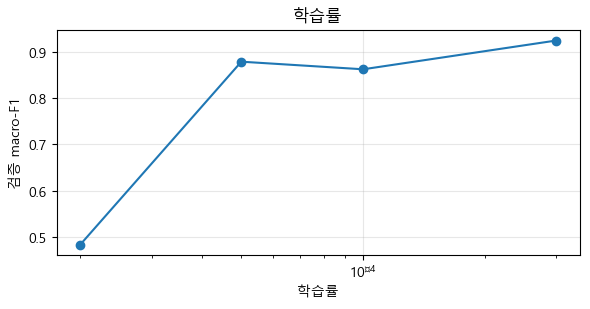

선정된 학습률: 0.0003  ※ 최적값이 구간 양 끝이면 구간을 넓혀 다시 돌린다


In [24]:
# (1) 학습률 — 수업 5-3: 미세조정은 작게
for lr in [3e-4, 1e-4, 5e-5, 2e-5]:
    run_experiment(f'LR_{lr:g}', preset=BEST_PRESET, lr=lr, epochs=SCREEN_EPOCHS, patience=8,
                   model_name=REF['model_name'], dropout=REF['dropout'],
                   use_class_weight=REF['use_class_weight'])
t = runs_table(); l = t[t.run_id.str.startswith('LR_')].sort_values('lr')
display(l[['run_id','lr','best_epoch','val_macro_f1','val_accuracy','val_loss']].round(5))
plt.figure(figsize=(6, 3.2)); plt.semilogx(l.lr, l.val_macro_f1, marker='o')
plt.xlabel('학습률'); plt.ylabel('검증 macro-F1'); plt.grid(alpha=.3); plt.title('학습률')
plt.tight_layout(); plt.show()
BEST_LR = float(l.sort_values('val_macro_f1', ascending=False).iloc[0].lr)
print('선정된 학습률:', BEST_LR, ' ※ 최적값이 구간 양 끝이면 구간을 넓혀 다시 돌린다')

In [25]:
# (2) 스케줄러 3종 (수업 3-15) / 드롭아웃 (2-10) / 클래스 가중치 (4-7)
for sch in ['plateau', 'cosine', 'step']:
    run_experiment(f'SCH_{sch}', preset=BEST_PRESET, lr=BEST_LR, scheduler=sch,
                   epochs=SCREEN_EPOCHS, patience=8, model_name=REF['model_name'],
                   dropout=REF['dropout'], use_class_weight=True)
t = runs_table(); s = t[t.run_id.str.startswith('SCH_')].sort_values('val_macro_f1', ascending=False)
display(s[['run_id','scheduler','best_epoch','val_macro_f1','val_loss']].round(5))
BEST_SCH = str(s.iloc[0].scheduler); print('선정된 스케줄러:', BEST_SCH)

grid = [dict(dropout=0.3, use_class_weight=True,  weight_decay=0.0),
        dict(dropout=0.5, use_class_weight=True,  weight_decay=0.0),
        dict(dropout=0.5, use_class_weight=False, weight_decay=0.0),
        dict(dropout=0.5, use_class_weight=True,  weight_decay=1e-4)]
for i, g in enumerate(grid):
    run_experiment(f'REG_{i}', preset=BEST_PRESET, lr=BEST_LR, scheduler=BEST_SCH,
                   epochs=SCREEN_EPOCHS, patience=8, model_name=REF['model_name'], **g)
t = runs_table(); r = t[t.run_id.str.startswith('REG_')].sort_values('val_macro_f1', ascending=False)
display(r[['run_id','dropout','class_weight','weight_decay','val_macro_f1','val_accuracy'] +
          [f'val_recall_{KOR[c]}' for c in CLASS_NAMES]].round(4))
r0 = r.iloc[0]
BEST_REG = dict(dropout=float(r0.dropout), use_class_weight=bool(int(r0.class_weight)),
                weight_decay=float(r0.weight_decay))
print('선정된 정규화:', BEST_REG)

=== SCH_plateau | efficientnet_v2_s | 증강 flip_rot | lr 0.0003 | 가중치 True | 학습 파라미터 20,182,612/20,182,612
[SCH_plateau]  1/15 loss 1.3702 acc 0.3319 | val_loss 1.3065 val_acc 0.4211 val_macroF1 0.2127 | lr 3.0e-04 (2.6s) 저장
[SCH_plateau]  2/15 loss 1.1967 acc 0.5354 | val_loss 0.8672 val_acc 0.6842 val_macroF1 0.5261 | lr 3.0e-04 (2.6s) 저장
[SCH_plateau]  3/15 loss 0.7168 acc 0.6814 | val_loss 0.4717 val_acc 0.8246 val_macroF1 0.8249 | lr 3.0e-04 (2.5s) 저장
[SCH_plateau]  4/15 loss 0.3726 acc 0.8673 | val_loss 0.9037 val_acc 0.8596 val_macroF1 0.8134 | lr 3.0e-04 (2.5s) 
[SCH_plateau]  5/15 loss 0.4982 acc 0.8186 | val_loss 0.3500 val_acc 0.8421 val_macroF1 0.8703 | lr 3.0e-04 (2.5s) 저장
[SCH_plateau]  6/15 loss 0.3174 acc 0.8894 | val_loss 0.3353 val_acc 0.8421 val_macroF1 0.8401 | lr 3.0e-04 (2.5s) 
[SCH_plateau]  7/15 loss 0.3333 acc 0.8584 | val_loss 0.5365 val_acc 0.8421 val_macroF1 0.7986 | lr 3.0e-04 (2.5s) 
[SCH_plateau]  8/15 loss 0.2578 acc 0.8673 | val_loss 0.4443 val_acc 0.8596

,run_id,scheduler,best_epoch,val_macro_f1,val_loss
14,SCH_cosine,cosine,13,0.93288,0.35676
15,SCH_step,step,10,0.91429,0.50795
13,SCH_plateau,plateau,8,0.89530,0.51400


선정된 스케줄러: cosine
=== REG_0 | efficientnet_v2_s | 증강 flip_rot | lr 0.0003 | 가중치 True | 학습 파라미터 20,182,612/20,182,612
[REG_0]  1/15 loss 1.3785 acc 0.3053 | val_loss 1.3432 val_acc 0.2807 val_macroF1 0.1546 | lr 3.0e-04 (2.5s) 저장
[REG_0]  2/15 loss 1.3337 acc 0.4027 | val_loss 1.1035 val_acc 0.6316 val_macroF1 0.4830 | lr 2.9e-04 (2.5s) 저장
[REG_0]  3/15 loss 0.9366 acc 0.6150 | val_loss 0.8680 val_acc 0.7368 val_macroF1 0.6728 | lr 2.7e-04 (2.5s) 저장
[REG_0]  4/15 loss 0.5042 acc 0.8496 | val_loss 0.7857 val_acc 0.7368 val_macroF1 0.6185 | lr 2.5e-04 (2.5s) 
[REG_0]  5/15 loss 0.7449 acc 0.7522 | val_loss 0.4413 val_acc 0.7719 val_macroF1 0.8205 | lr 2.3e-04 (2.6s) 저장
[REG_0]  6/15 loss 0.2812 acc 0.9115 | val_loss 0.3691 val_acc 0.8246 val_macroF1 0.8840 | lr 2.0e-04 (2.5s) 저장
[REG_0]  7/15 loss 0.3076 acc 0.8628 | val_loss 0.3337 val_acc 0.7895 val_macroF1 0.8649 | lr 1.7e-04 (2.5s) 
[REG_0]  8/15 loss 0.2125 acc 0.8805 | val_loss 0.4028 val_acc 0.8596 val_macroF1 0.8953 | lr 1.3e-04 (2

,run_id,dropout,class_weight,weight_decay,val_macro_f1,val_accuracy,val_recall_호산구,val_recall_림프구,val_recall_단핵구,val_recall_호중구
18,REG_2,0.5,0,0.0000,0.9215,0.8947,0.6667,1.0,1.0,0.9706
19,REG_3,0.5,1,0.0001,0.9215,0.8947,0.6667,1.0,1.0,0.9706
17,REG_1,0.5,1,0.0000,0.9105,0.8772,0.6667,1.0,1.0,0.9412
16,REG_0,0.3,1,0.0000,0.9000,0.8596,0.6667,1.0,1.0,0.9118


선정된 정규화: {'dropout': 0.5, 'use_class_weight': False, 'weight_decay': 0.0}


In [26]:
# (3) 백본 후보 — 3분 예산을 통과한 것들끼리
CAND = [m for m in ['efficientnet_v2_s', 'efficientnet_b0', 'resnet18', 'resnet34']
        if bool(probe.loc[(probe.model == m) & (~probe.freeze), 'fits'].max()) or
           m not in probe.model.values]
print('비교 대상:', CAND)
for m in CAND:
    run_experiment(f'BB_{m}', model_name=m, preset=BEST_PRESET, lr=BEST_LR, scheduler=BEST_SCH,
                   epochs=SCREEN_EPOCHS, patience=8, **BEST_REG)
t = runs_table(); c = t[t.run_id.str.startswith('BB_')].sort_values('val_macro_f1', ascending=False)
display(c[['run_id','params_M','epoch_sec','best_epoch','val_macro_f1','val_accuracy']].round(4))

ok = c[c.epoch_sec <= EPOCH_BUDGET]
top = ok.val_macro_f1.max()
near = ok[ok.val_macro_f1 >= top - 0.01]           # 최고와 1%p 이내면 동급으로 본다
pick = near.sort_values('epoch_sec').iloc[0]
BEST_MODEL = pick.run_id[3:]; TOP_MODEL = c.iloc[0].run_id[3:]
print(f'최고 성능 : {TOP_MODEL} ({top:.4f})')
print(f'최종 선정 : {BEST_MODEL} ({pick.val_macro_f1:.4f}, {pick.epoch_sec:.1f}s, {pick.params_M}M)')
print('  기준 1) 3분 예산 준수  2) 최고와 1%p 이내  3) 그중 가장 빠름')

비교 대상: ['efficientnet_v2_s', 'efficientnet_b0', 'resnet18', 'resnet34']
=== BB_efficientnet_v2_s | efficientnet_v2_s | 증강 flip_rot | lr 0.0003 | 가중치 False | 학습 파라미터 20,182,612/20,182,612
[BB_efficientnet_v2_s]  1/15 loss 1.2150 acc 0.4823 | val_loss 1.1859 val_acc 0.5965 val_macroF1 0.1868 | lr 3.0e-04 (2.6s) 저장
[BB_efficientnet_v2_s]  2/15 loss 1.0183 acc 0.6283 | val_loss 0.8297 val_acc 0.6667 val_macroF1 0.3136 | lr 2.9e-04 (2.5s) 저장
[BB_efficientnet_v2_s]  3/15 loss 0.7105 acc 0.7168 | val_loss 0.6050 val_acc 0.8246 val_macroF1 0.7520 | lr 2.7e-04 (2.5s) 저장
[BB_efficientnet_v2_s]  4/15 loss 0.3896 acc 0.8938 | val_loss 0.5133 val_acc 0.8772 val_macroF1 0.9006 | lr 2.5e-04 (2.5s) 저장
[BB_efficientnet_v2_s]  5/15 loss 0.3730 acc 0.8938 | val_loss 0.5274 val_acc 0.8421 val_macroF1 0.8465 | lr 2.3e-04 (2.6s) 
[BB_efficientnet_v2_s]  6/15 loss 0.2460 acc 0.9204 | val_loss 0.4107 val_acc 0.8947 val_macroF1 0.9172 | lr 2.0e-04 (2.7s) 저장
[BB_efficientnet_v2_s]  7/15 loss 0.2795 acc 0.9115 |

100%|██████████| 20.5M/20.5M [00:00<00:00, 76.8MB/s]


=== BB_efficientnet_b0 | efficientnet_b0 | 증강 flip_rot | lr 0.0003 | 가중치 False | 학습 파라미터 4,012,672/4,012,672
[BB_efficientnet_b0]  1/15 loss 1.2214 acc 0.5088 | val_loss 1.1141 val_acc 0.5789 val_macroF1 0.2553 | lr 3.0e-04 (4.6s) 저장
[BB_efficientnet_b0]  2/15 loss 0.8652 acc 0.6681 | val_loss 0.8712 val_acc 0.6842 val_macroF1 0.4742 | lr 2.9e-04 (1.6s) 저장
[BB_efficientnet_b0]  3/15 loss 0.6527 acc 0.8053 | val_loss 0.7013 val_acc 0.7368 val_macroF1 0.5460 | lr 2.7e-04 (1.7s) 저장
[BB_efficientnet_b0]  4/15 loss 0.4880 acc 0.8673 | val_loss 0.4856 val_acc 0.8421 val_macroF1 0.8850 | lr 2.5e-04 (1.7s) 저장
[BB_efficientnet_b0]  5/15 loss 0.4320 acc 0.8850 | val_loss 0.5586 val_acc 0.8421 val_macroF1 0.8367 | lr 2.3e-04 (1.7s) 
[BB_efficientnet_b0]  6/15 loss 0.2523 acc 0.9336 | val_loss 0.4383 val_acc 0.8596 val_macroF1 0.8953 | lr 2.0e-04 (1.7s) 저장
[BB_efficientnet_b0]  7/15 loss 0.2374 acc 0.9425 | val_loss 0.4600 val_acc 0.8596 val_macroF1 0.8953 | lr 1.7e-04 (1.8s) 
[BB_efficientnet_b0]

100%|██████████| 44.7M/44.7M [00:00<00:00, 83.2MB/s]


=== BB_resnet18 | resnet18 | 증강 flip_rot | lr 0.0003 | 가중치 False | 학습 파라미터 11,178,564/11,178,564
[BB_resnet18]  1/15 loss 1.2133 acc 0.5354 | val_loss 1.2156 val_acc 0.5614 val_macroF1 0.1839 | lr 3.0e-04 (2.8s) 저장
[BB_resnet18]  2/15 loss 0.9259 acc 0.6637 | val_loss 1.0974 val_acc 0.6140 val_macroF1 0.4055 | lr 2.9e-04 (1.4s) 저장
[BB_resnet18]  3/15 loss 0.6142 acc 0.7434 | val_loss 1.0110 val_acc 0.6842 val_macroF1 0.3896 | lr 2.7e-04 (1.5s) 
[BB_resnet18]  4/15 loss 0.5233 acc 0.7832 | val_loss 0.7457 val_acc 0.6667 val_macroF1 0.7234 | lr 2.5e-04 (1.5s) 저장
[BB_resnet18]  5/15 loss 0.4095 acc 0.8363 | val_loss 0.5482 val_acc 0.8070 val_macroF1 0.8744 | lr 2.3e-04 (1.5s) 저장
[BB_resnet18]  6/15 loss 0.3465 acc 0.8850 | val_loss 0.4788 val_acc 0.8772 val_macroF1 0.8443 | lr 2.0e-04 (1.4s) 
[BB_resnet18]  7/15 loss 0.2192 acc 0.9381 | val_loss 0.5492 val_acc 0.7895 val_macroF1 0.8282 | lr 1.7e-04 (1.4s) 
[BB_resnet18]  8/15 loss 0.2003 acc 0.9292 | val_loss 0.2819 val_acc 0.8772 val_mac

100%|██████████| 83.3M/83.3M [00:01<00:00, 84.9MB/s]


=== BB_resnet34 | resnet34 | 증강 flip_rot | lr 0.0003 | 가중치 False | 학습 파라미터 21,286,724/21,286,724
[BB_resnet34]  1/15 loss 1.5008 acc 0.3496 | val_loss 0.7191 val_acc 0.7018 val_macroF1 0.4912 | lr 3.0e-04 (1.7s) 저장
[BB_resnet34]  2/15 loss 0.7905 acc 0.7257 | val_loss 0.7159 val_acc 0.7018 val_macroF1 0.5377 | lr 2.9e-04 (1.8s) 저장
[BB_resnet34]  3/15 loss 0.5066 acc 0.8142 | val_loss 0.5263 val_acc 0.8596 val_macroF1 0.8641 | lr 2.7e-04 (1.8s) 저장
[BB_resnet34]  4/15 loss 0.4556 acc 0.8496 | val_loss 0.6898 val_acc 0.7719 val_macroF1 0.7175 | lr 2.5e-04 (1.8s) 
[BB_resnet34]  5/15 loss 0.3552 acc 0.8717 | val_loss 0.6235 val_acc 0.8421 val_macroF1 0.9000 | lr 2.3e-04 (1.8s) 저장
[BB_resnet34]  6/15 loss 0.2570 acc 0.8894 | val_loss 0.4609 val_acc 0.8596 val_macroF1 0.8953 | lr 2.0e-04 (1.8s) 
[BB_resnet34]  7/15 loss 0.2154 acc 0.9204 | val_loss 0.5526 val_acc 0.8246 val_macroF1 0.8874 | lr 1.7e-04 (1.8s) 
[BB_resnet34]  8/15 loss 0.2195 acc 0.9204 | val_loss 0.4033 val_acc 0.8772 val_mac

,run_id,params_M,epoch_sec,best_epoch,val_macro_f1,val_accuracy
22,BB_resnet18,11.18,1.54,10,0.9410,0.9123
21,BB_efficientnet_b0,4.01,1.91,11,0.9250,0.8947
20,BB_efficientnet_v2_s,20.18,2.59,6,0.9172,0.8947
23,BB_resnet34,21.29,1.80,11,0.9105,0.8772


최고 성능 : resnet18 (0.9410)
최종 선정 : resnet18 (0.9410, 1.5s, 11.18M)
  기준 1) 3분 예산 준수  2) 최고와 1%p 이내  3) 그중 가장 빠름


---
# §14. 최종 설정 확정

**여기까지가 "검증셋으로 고르는" 단계다.** 아래 설정을 확정한 뒤에는 바꾸지 않는다.

In [27]:
FINAL_CFG = dict(model_name=BEST_MODEL, preset=BEST_PRESET, lr=BEST_LR,
                 scheduler=BEST_SCH, **BEST_REG)
print(json.dumps(FINAL_CFG, ensure_ascii=False, indent=1))
json.dump(FINAL_CFG, open('best_config.json','w',encoding='utf-8'), ensure_ascii=False, indent=1)

t = runs_table()
print(f'\n지금까지 {len(t)}건의 실험을 검증셋으로만 비교했다. test 는 아직 열지 않았다.')
display(t.sort_values('val_macro_f1', ascending=False)
        [['run_id','model','preset','lr','scheduler','dropout','class_weight',
          'best_epoch','epoch_sec','val_macro_f1','val_accuracy']].head(12).round(4))

{
 "model_name": "resnet18",
 "preset": "flip_rot",
 "lr": 0.0003,
 "scheduler": "cosine",
 "dropout": 0.5,
 "use_class_weight": false,
 "weight_decay": 0.0
}

지금까지 24건의 실험을 검증셋으로만 비교했다. test 는 아직 열지 않았다.


,run_id,model,preset,lr,scheduler,dropout,class_weight,best_epoch,epoch_sec,val_macro_f1,val_accuracy
22,BB_resnet18,resnet18,flip_rot,0.0003,cosine,0.5,0,10,1.54,0.9410,0.9123
14,SCH_cosine,efficientnet_v2_s,flip_rot,0.0003,cosine,0.5,1,13,2.52,0.9329,0.9123
9,LR_0.0003,efficientnet_v2_s,flip_rot,0.0003,plateau,0.5,1,15,2.53,0.9250,0.8947
21,BB_efficientnet_b0,efficientnet_b0,flip_rot,0.0003,cosine,0.5,0,11,1.91,0.9250,0.8947
19,REG_3,efficientnet_v2_s,flip_rot,0.0003,cosine,0.5,1,13,2.57,0.9215,0.8947
18,REG_2,efficientnet_v2_s,flip_rot,0.0003,cosine,0.5,0,7,2.51,0.9215,0.8947
20,BB_efficientnet_v2_s,efficientnet_v2_s,flip_rot,0.0003,cosine,0.5,0,6,2.59,0.9172,0.8947
6,AUG_flip_rot,efficientnet_v2_s,flip_rot,0.0001,plateau,0.5,1,10,2.53,0.9143,0.8772
8,AUG_color,efficientnet_v2_s,color,0.0001,plateau,0.5,1,11,3.01,0.9143,0.8772
15,SCH_step,efficientnet_v2_s,flip_rot,0.0003,step,0.5,1,10,2.52,0.9143,0.8772


---
# §15. 최종 평가 — 반복 홀드아웃 5회 ⭐

**여기서 처음으로 test 를 연다.**

## 왜 한 번만 재지 않고 5번 반복하나

test 는 71장이고 그중 단핵구는 4장뿐이다. **한 번의 결과는 대부분 운**이다.
수업에는 K-Fold 교차검증이 없으므로, **배운 것으로 같은 목적을 달성**한다.

> **📘 수업 4-3**: `train_test_split(..., random_state=seed)`
> → **시드를 바꾸면 다른 분할이 나온다.** 이걸 5번 반복해 **평균 ± 표준편차**로 보고한다.

**규칙 (이걸 지켜야 정답 유출이 없다)**

1. §14 에서 확정한 설정을 **한 글자도 바꾸지 않는다**
2. 시드마다 분할을 새로 만들고, **그 시드의 train 으로만 학습**한다
3. 조기종료·체크포인트는 **그 시드의 val** 로만 판단한다
4. test 는 학습이 끝난 뒤 **한 번 채점**하고, 그 결과를 보고 아무것도 바꾸지 않는다

**test 는 어떤 시드에서도 학습·선택에 관여하지 않는다.**

In [28]:
def run_one_seed(cfg, seed, epochs=None, verbose=False):
    epochs = epochs or FULL_EPOCHS
    split = make_split(seed)
    (a_x, a_y), (b_x, b_y), (c_x, c_y) = split
    set_seed(seed)
    l_tr, l_va, l_te = make_loaders(cfg['preset'], split=split)
    model = build_model(cfg['model_name'], pretrained=True, freeze=False,
                        dropout=cfg['dropout'], image_size=IMAGE_SIZE)
    cw = class_weights_from(a_y) if cfg['use_class_weight'] else None
    hist = train_model(model, l_tr, l_va, epochs=epochs, lr=cfg['lr'],
                       weight_decay=cfg['weight_decay'], class_weight=cw,
                       scheduler=cfg['scheduler'], patience=10,
                       ckpt_path=f'{RESULT_DIR}/ckpt/FINAL_s{seed}.pt',
                       label=f'FINAL_s{seed}', verbose=verbose)
    model.load_state_dict(torch.load(hist['ckpt_path'], map_location=device))
    m_va = evaluate(model, l_va)
    m_te = evaluate(model, l_te, nn.CrossEntropyLoss())       # ← 여기서 딱 한 번
    return model, hist, m_va, m_te, split

rep_rows, rep_test, rep_models = [], {}, {}
for sd in SEEDS:
    model, hist, m_va, m_te, split = run_one_seed(FINAL_CFG, sd)
    rep_test[sd] = m_te; rep_models[sd] = (model.to('cpu'), split)   # GPU 메모리 절약
    rep_rows.append(dict(seed=sd, best_epoch=hist['best_epoch'], epoch_sec=hist['epoch_sec_mean'],
                         val_macro_f1=m_va['macro_f1'],
                         test_accuracy=m_te['accuracy'], test_macro_f1=m_te['macro_f1'],
                         test_balanced=m_te['balanced'], test_auc=m_te['auc'],
                         **{f'재현율_{KOR[c]}': m_te['recall_per_class'][i]
                            for i, c in enumerate(CLASS_NAMES)}))
    print(f'  seed {sd}: val macroF1 {m_va["macro_f1"]:.4f} | '
          f'TEST 정확도 {m_te["accuracy"]:.4f} macroF1 {m_te["macro_f1"]:.4f} '
          f'({hist["epochs_run"]}에폭, 에폭당 {hist["epoch_sec_mean"]:.1f}s)')

rep = pd.DataFrame(rep_rows)
display(rep.round(4))

  seed 42: val macroF1 0.9388 | TEST 정확도 0.8028 macroF1 0.7373 (38에폭, 에폭당 1.4s)
  seed 0: val macroF1 0.9878 | TEST 정확도 0.9014 macroF1 0.8312 (30에폭, 에폭당 1.4s)
  seed 1: val macroF1 0.8523 | TEST 정확도 0.8732 macroF1 0.8239 (26에폭, 에폭당 1.5s)
  seed 2: val macroF1 0.9172 | TEST 정확도 0.8873 macroF1 0.9071 (19에폭, 에폭당 1.5s)
  seed 3: val macroF1 0.8722 | TEST 정확도 0.7887 macroF1 0.7058 (18에폭, 에폭당 1.5s)


,seed,best_epoch,epoch_sec,val_macro_f1,test_accuracy,test_macro_f1,test_balanced,test_auc,재현율_호산구,재현율_림프구,재현율_단핵구,재현율_호중구
0,42,28,1.3958,0.9388,0.8028,0.7373,0.7183,0.9291,0.6111,0.8571,0.50,0.9048
1,0,20,1.4015,0.9878,0.9014,0.8312,0.8185,0.9749,0.8333,0.7143,0.75,0.9762
2,1,16,1.4531,0.8523,0.8732,0.8239,0.8016,0.9775,0.7778,1.0000,0.50,0.9286
3,2,9,1.4605,0.9172,0.8873,0.9071,0.8988,0.9785,0.8333,0.8571,1.00,0.9048
4,3,8,1.5036,0.8722,0.7887,0.7058,0.7183,0.9069,0.4444,1.0000,0.50,0.9286


,test_accuracy,test_macro_f1,test_balanced,test_auc
mean,0.8507,0.8010,0.7911,0.9534
std,0.0514,0.0803,0.0759,0.0333


★ 최종 성능 (반복 홀드아웃 5회, 원본 354장, 누수 0)
  정확도       0.8507 ± 0.0514
  macro-F1  0.8010 ± 0.0803
  균형정확도     0.7911 ± 0.0759
  macro AUC 0.9534 ± 0.0333
  비교 — 전부 호중구로 찍기 정확도 0.5932 / 무작위 0.2500


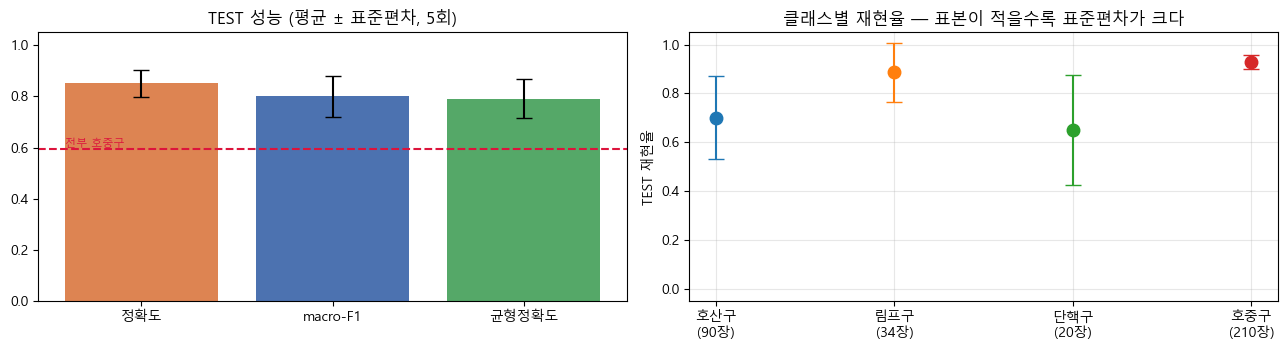

In [29]:
summary_stats = rep[['test_accuracy','test_macro_f1','test_balanced','test_auc']].agg(['mean','std']).round(4)
display(summary_stats)

print('=' * 74)
print('★ 최종 성능 (반복 홀드아웃 %d회, 원본 354장, 누수 0)' % len(SEEDS))
for k, kor in [('test_accuracy','정확도'), ('test_macro_f1','macro-F1'),
               ('test_balanced','균형정확도'), ('test_auc','macro AUC')]:
    print(f'  {kor:9s} {rep[k].mean():.4f} ± {rep[k].std():.4f}')
print(f'  비교 — 전부 {KOR[CLASS_NAMES[int(cnt.argmax())]]}로 찍기 정확도 {major:.4f} / 무작위 {1/NUM_CLASSES:.4f}')
print('=' * 74)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(['정확도','macro-F1','균형정확도'],
          [rep.test_accuracy.mean(), rep.test_macro_f1.mean(), rep.test_balanced.mean()],
          yerr=[rep.test_accuracy.std(), rep.test_macro_f1.std(), rep.test_balanced.std()],
          capsize=6, color=['#DD8452','#4C72B0','#55A868'])
ax[0].axhline(major, ls='--', c='crimson'); ax[0].text(-0.4, major+0.01, '전부 호중구', color='crimson', fontsize=8)
ax[0].set_ylim(0, 1.05); ax[0].set_title(f'TEST 성능 (평균 ± 표준편차, {len(SEEDS)}회)')
for i, c in enumerate(CLASS_NAMES):
    ax[1].errorbar([i], [rep[f'재현율_{KOR[c]}'].mean()], yerr=[rep[f'재현율_{KOR[c]}'].std()],
                   fmt='o', capsize=6, ms=9)
ax[1].set_xticks(range(NUM_CLASSES)); ax[1].set_xticklabels([f'{KOR[c]}\n({cnt[i]}장)' for i, c in enumerate(CLASS_NAMES)])
ax[1].set_ylim(-0.05, 1.05); ax[1].set_ylabel('TEST 재현율'); ax[1].grid(alpha=.3)
ax[1].set_title('클래스별 재현율 — 표본이 적을수록 표준편차가 크다')
plt.tight_layout(); plt.show()

### 이 숫자를 어떻게 말해야 하나

- **"정확도 X"가 아니라 "X ± s"** 로 말한다. 표준편차가 곧 이 데이터의 한계다.
- **단핵구 재현율의 표준편차가 크다면** 그건 모델 탓이 아니라 **test 에 4장뿐이기 때문**이다.
  한 장 더 맞히면 0.25가 오르내린다. 이걸 명시하는 것이 정직한 보고다.
- **기준선 0(전부 호중구, 정확도 0.59)** 과 반드시 나란히 놓는다.

---
# §16. 대표 1회 상세 평가

시드 하나(첫 번째)를 골라 혼동행렬·클래스별 지표·오분류·ROC 를 자세히 본다.
**§15 의 결론을 바꾸지 않는다.** 설명을 위한 확대경일 뿐이다.

TEST (seed 42)             acc 0.8028  macroF1 0.7373  balanced 0.7183  AUC 0.9291
분모 확인: 71장 — test 분할 장수와 같아야 한다


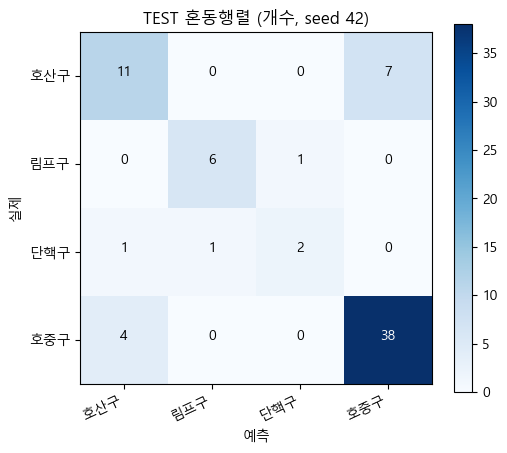

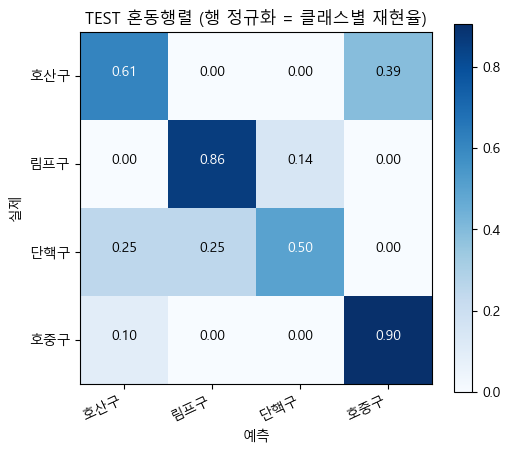

,precision,recall,f1-score,support
호산구,0.6875,0.6111,0.6471,18.0000
림프구,0.8571,0.8571,0.8571,7.0000
단핵구,0.6667,0.5000,0.5714,4.0000
호중구,0.8444,0.9048,0.8736,42.0000
accuracy,0.8028,0.8028,0.8028,0.8028
macro avg,0.7639,0.7183,0.7373,71.0000
weighted avg,0.7959,0.8028,0.7975,71.0000


가장 많이 혼동한 쌍 (실제 → 예측)
  호산구 → 호중구 : 7장
  호중구 → 호산구 : 4장
  림프구 → 단핵구 : 1장
  단핵구 → 호산구 : 1장


In [30]:
SEED0 = SEEDS[0]
final_model, split0 = rep_models[SEED0]
final_model = final_model.to(device).eval()
m_test = rep_test[SEED0]
print(summarize(m_test, f'TEST (seed {SEED0})'))
print(f'분모 확인: {len(m_test["trues"])}장 — test 분할 장수와 같아야 한다')

cm = plot_confusion(m_test['trues'], m_test['preds'], title=f'TEST 혼동행렬 (개수, seed {SEED0})')
plot_confusion(m_test['trues'], m_test['preds'], normalize=True,
               title='TEST 혼동행렬 (행 정규화 = 클래스별 재현율)')
display(pd.DataFrame(classification_report(
    m_test['trues'], m_test['preds'], labels=range(NUM_CLASSES),
    target_names=[KOR[c] for c in CLASS_NAMES], output_dict=True, zero_division=0)).T.round(4))

pairs = sorted([(KOR[CLASS_NAMES[i]], KOR[CLASS_NAMES[j]], int(cm[i,j]))
                for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j], key=lambda z: -z[2])
print('가장 많이 혼동한 쌍 (실제 → 예측)')
for a_, b_, n_ in pairs[:4]: print(f'  {a_} → {b_} : {n_}장')

In [31]:
def bootstrap_ci(y_true, y_pred, metric='accuracy', n_boot=2000, alpha=0.05, seed=42):
    """테스트셋을 복원추출로 다시 뽑아 반복 측정 → 추정값이 흔들리는 폭"""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    fn = {'accuracy': accuracy_score,
          'macro_f1': lambda a, b: f1_score(a, b, average='macro', zero_division=0),
          'balanced': balanced_accuracy_score}[metric]
    rs = np.random.RandomState(seed); n = len(y_true); v = []
    for _ in range(n_boot):
        i = rs.randint(0, n, n)
        if len(np.unique(y_true[i])) < 2: continue
        v.append(fn(y_true[i], y_pred[i]))
    v = np.array(v)
    return dict(point=float(fn(y_true, y_pred)),
                lo=float(np.percentile(v, 100*alpha/2)), hi=float(np.percentile(v, 100*(1-alpha/2))))

ci_test = {}
print(f'seed {SEED0} TEST — 95% 신뢰구간 (71장 안에서의 흔들림)')
for met in ['accuracy','macro_f1','balanced']:
    ci_test[met] = bootstrap_ci(m_test['trues'], m_test['preds'], met)
    print(f'  {met:9s} {ci_test[met]["point"]:.4f}  [{ci_test[met]["lo"]:.4f}, {ci_test[met]["hi"]:.4f}]')
print('※ §15 의 표준편차는 "분할을 바꿨을 때의 흔들림", 여기 신뢰구간은 "같은 분할 안에서의 흔들림"이다.')
print('  둘은 다른 것을 재며, 보고서에는 둘 다 쓰는 것이 좋다.')

seed 42 TEST — 95% 신뢰구간 (71장 안에서의 흔들림)
  accuracy  0.8028  [0.7183, 0.8873]
  macro_f1  0.7373  [0.5472, 0.8802]


c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains clas

  balanced  0.7183  [0.5439, 0.8785]
※ §15 의 표준편차는 "분할을 바꿨을 때의 흔들림", 여기 신뢰구간은 "같은 분할 안에서의 흔들림"이다.
  둘은 다른 것을 재며, 보고서에는 둘 다 쓰는 것이 좋다.


c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains clas

틀린 것 14장 / 71장


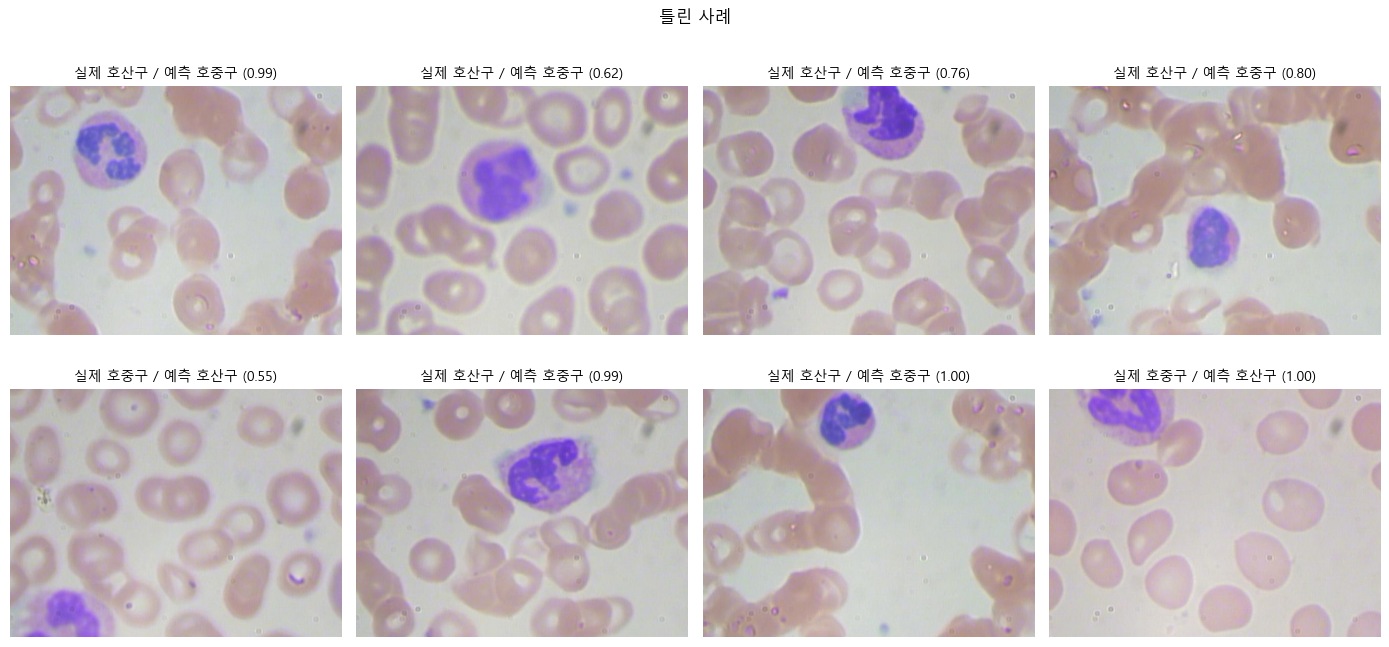

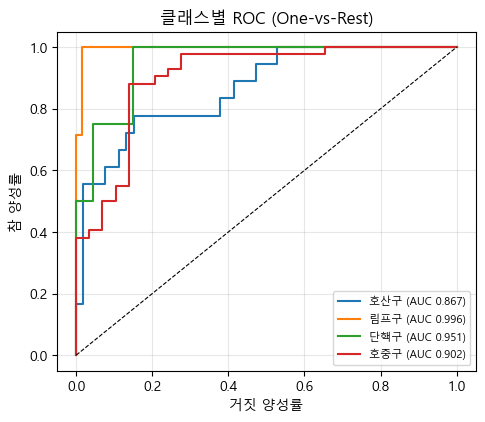

In [32]:
# 오분류 들여다보기 (수업 3-10)
(_, _), (_, _), (te_x0, te_y0) = split0
wrong = np.where(m_test['preds'] != m_test['trues'])[0]
print(f'틀린 것 {len(wrong)}장 / {len(m_test["trues"])}장')
if len(wrong):
    sel = np.random.RandomState(0).choice(wrong, min(8, len(wrong)), replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7)); axes = axes.ravel()
    for ax_, i in zip(axes, sel):
        ax_.imshow(Image.open(te_x0[i])); ax_.axis('off')
        p = m_test['preds'][i]; conf = m_test['probs'][i][p]
        ax_.set_title(f'실제 {KOR[CLASS_NAMES[m_test["trues"][i]]]} / '
                      f'예측 {KOR[CLASS_NAMES[p]]} ({conf:.2f})', fontsize=10)
    for ax_ in axes[len(sel):]: ax_.axis('off')
    plt.suptitle('틀린 사례'); plt.tight_layout(); plt.show()

# 클래스별 ROC (수업 2-8: ROC 는 이진용이라 다중분류는 One-vs-Rest 로)
plt.figure(figsize=(5.4, 4.4))
for c, name in enumerate(CLASS_NAMES):
    yb_ = (m_test['trues'] == c).astype(int)
    if yb_.sum() == 0: continue
    fpr, tpr, _ = roc_curve(yb_, m_test['probs'][:, c])
    plt.plot(fpr, tpr, label=f'{KOR[name]} (AUC {roc_auc_score(yb_, m_test["probs"][:,c]):.3f})')
plt.plot([0,1],[0,1],'k--',lw=.8); plt.xlabel('거짓 양성률'); plt.ylabel('참 양성률')
plt.title('클래스별 ROC (One-vs-Rest)'); plt.legend(fontsize=8); plt.grid(alpha=.3); plt.show()

---
# §17. Grad-CAM — 모델이 어디를 보고 판단했는가

**과제 필수 항목.** 정확도가 높아도 **배경 적혈구를 외운 모델**이면 쓸 수 없다.

> **📘 수업 `5.ipynb` 의 `GradCAM` 클래스를 그대로 가져왔다.**
> 이진 분류용이라 **두 곳만 고쳤다.**
>
> | 5.ipynb (이진) | 여기 (4클래스) |
> |---|---|
> | `logit = model(x).squeeze(); logit.backward()` | **`logits[0, class_idx].backward()`** — 클래스를 지정할 수 있어야 "왜 호산구가 아니라 호중구인가"를 비교할 수 있다 |
> | `target_layer = best.backbone.stages[-1]` | **마지막 `Conv2d` 층을 자동으로 찾는다** — 백본이 바뀌어도 돌아간다 |
>
> `overlay_heatmap` 은 수업 코드 그대로다.

In [33]:
class GradCAM:
    """수업 5.ipynb 의 GradCAM. 다중 분류용으로 backward 대상만 바꿨다"""
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.acts = None
        self.grads = None
        self.handles = [target_layer.register_forward_hook(self._save_acts),
                        target_layer.register_full_backward_hook(self._save_grads)]

    def _save_acts(self, module, inp, out):   self.acts = out.detach()
    def _save_grads(self, module, gi, go):    self.grads = go[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        x = x.clone().requires_grad_(True)          # 백본을 고정한 모델에서도 기울기가 흐르도록
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(1))
        logits[0, class_idx].backward()             # ← 이진용 logit.backward() 에서 변경
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        heat = (weights * self.acts).sum(dim=1).squeeze(0)
        heat = torch.relu(heat)
        if heat.max() > 0:
            heat = heat / heat.max()
        return heat.cpu().numpy(), class_idx

    def remove(self):
        for h in self.handles: h.remove()


def overlay_heatmap(heat, img01, alpha=0.4):        # 수업 5.ipynb 그대로
    h = torch.from_numpy(heat)[None, None]
    h = F.interpolate(h, size=img01.shape[:2], mode='bilinear', align_corners=False)[0, 0].numpy()
    jet = plt.get_cmap('jet')(h)[:, :, :3]
    return np.clip(img01*(1-alpha) + jet*alpha, 0, 1)


def last_conv(model):
    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    return convs[-1]

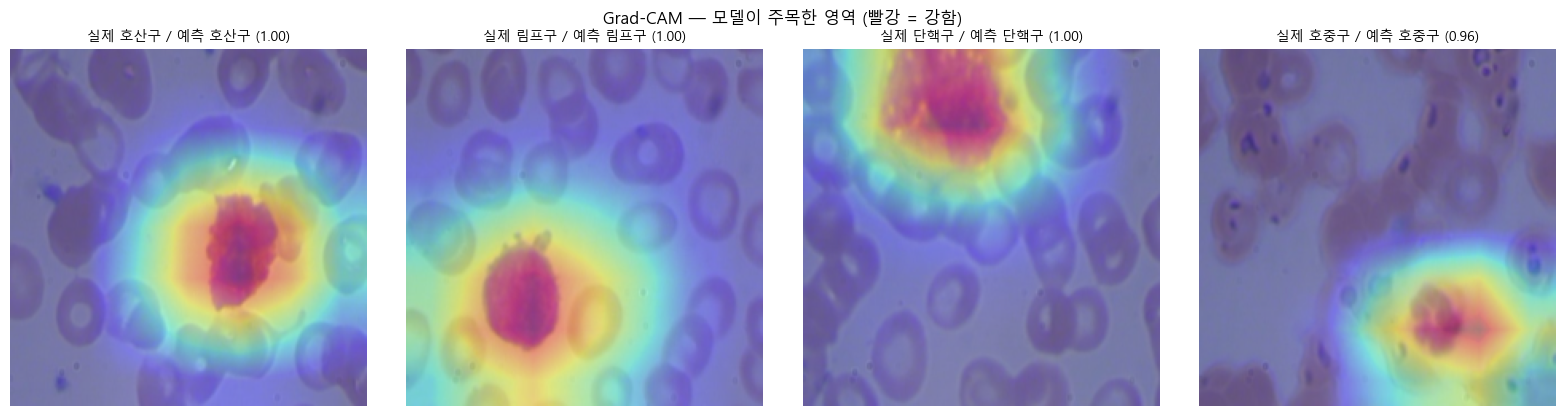

In [34]:
ds_te0 = BloodCellDataset(te_x0, te_y0, build_eval_tf())
correct = np.where(m_test['preds'] == m_test['trues'])[0]
rs = np.random.RandomState(0)
def pick(c):
    ci = np.where(m_test['trues'] == c)[0]
    if len(ci) == 0: return None
    okk = np.intersect1d(correct, ci)
    return int(rs.choice(okk if len(okk) else ci))
idx4 = [i for i in (pick(c) for c in range(NUM_CLASSES)) if i is not None]

cam = GradCAM(final_model, last_conv(final_model))
fig, ax = plt.subplots(1, len(idx4), figsize=(4*len(idx4), 4.2))
ax = np.atleast_1d(ax)
for k, i in enumerate(idx4):
    x, y = ds_te0[i]
    heat, _ = cam(x.unsqueeze(0).to(device))
    img01 = denorm(x)
    p = m_test['preds'][i]; conf = m_test['probs'][i][p]
    ax[k].imshow(overlay_heatmap(heat, img01))
    ax[k].set_title(f'실제 {KOR[CLASS_NAMES[y]]} / 예측 {KOR[CLASS_NAMES[p]]} ({conf:.2f})', fontsize=10)
    ax[k].axis('off')
plt.suptitle('Grad-CAM — 모델이 주목한 영역 (빨강 = 강함)'); plt.tight_layout(); plt.show()

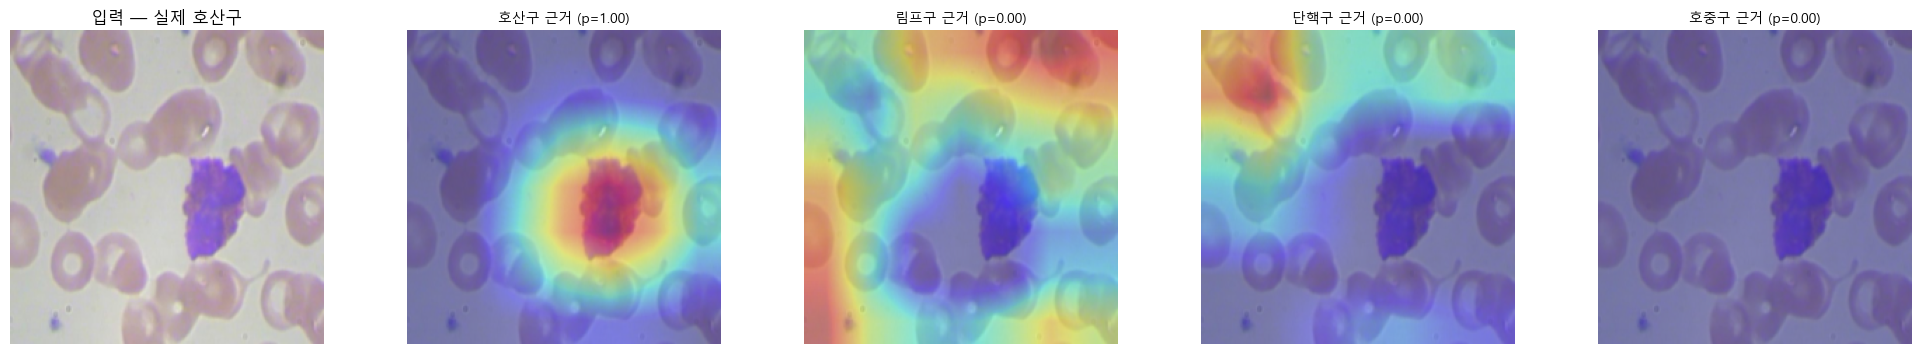

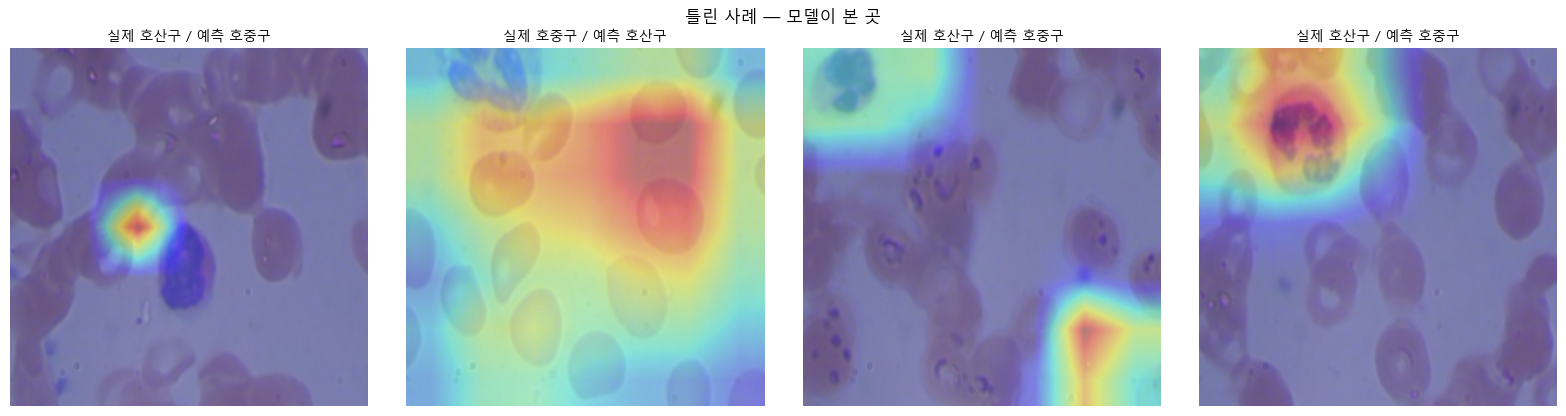

In [35]:
# 같은 세포를 네 클래스 관점에서 각각 본다 — "왜 A가 아니라 B인가"
i = idx4[0]
x, y = ds_te0[i]; img01 = denorm(x)
fig, ax = plt.subplots(1, NUM_CLASSES+1, figsize=(4*(NUM_CLASSES+1), 3.6))
ax[0].imshow(img01); ax[0].set_title(f'입력 — 실제 {KOR[CLASS_NAMES[y]]}'); ax[0].axis('off')
for c in range(NUM_CLASSES):
    heat, _ = cam(x.unsqueeze(0).to(device), class_idx=c)
    ax[c+1].imshow(overlay_heatmap(heat, img01))
    ax[c+1].set_title(f'{KOR[CLASS_NAMES[c]]} 근거 (p={m_test["probs"][i][c]:.2f})', fontsize=10)
    ax[c+1].axis('off')
plt.tight_layout(); plt.show()

# 틀린 사례의 Grad-CAM — 가장 배울 게 많다
if len(wrong):
    wsel = rs.choice(wrong, min(4, len(wrong)), replace=False)
    fig, ax = plt.subplots(1, len(wsel), figsize=(4*len(wsel), 4.2)); ax = np.atleast_1d(ax)
    for k, i in enumerate(wsel):
        x, y = ds_te0[int(i)]
        heat, _ = cam(x.unsqueeze(0).to(device))
        p = m_test['preds'][i]
        ax[k].imshow(overlay_heatmap(heat, denorm(x)))
        ax[k].set_title(f'실제 {KOR[CLASS_NAMES[y]]} / 예측 {KOR[CLASS_NAMES[p]]}', fontsize=10)
        ax[k].axis('off')
    plt.suptitle('틀린 사례 — 모델이 본 곳'); plt.tight_layout(); plt.show()
cam.remove()

### 무엇을 확인해야 하나

1. **히트맵이 가운데 백혈구 위에 있는가?** 주변 적혈구나 화면 가장자리에 몰려 있으면
   모델이 엉뚱한 단서를 배운 것이고, 점수가 높아도 신뢰할 수 없다.
2. **틀린 사례에서는 어디를 보고 있는가?** 백혈구가 두 개 있거나 가장자리에 잘려 있는 경우가 전형적이다.
3. 네 클래스 CAM 을 나란히 보면 **모델이 각 클래스의 근거로 삼는 위치가 다른지** 알 수 있다.

> **한계**: Grad-CAM 은 "어디를 봤나"까지만 말해 준다.
> "핵의 분엽 수를 세고 있다"까지는 이 그림으로 주장할 수 없다.

---
# §18. 확신도 임계값 — 보류 정책

> **📘 수업 `5.ipynb`**: 임계값을 0.05 씩 바꿔가며 민감도·특이도를 재고,
> **"민감도 99% 이상을 만족하는 것 중 특이도가 가장 높은 임계값"** 을 골랐다.
> 4클래스에서는 임계값 하나로 클래스를 가를 수 없으므로 **최대 확률(확신도)에 임계값을 건다.**
> τ 미만은 **"판독 보류 — 전문가 재확인"** 으로 넘긴다.

같은 사고방식이다 — **목표 정확도를 정하고, 그걸 만족하는 것 중 사람이 가장 덜 보는 지점**을 고른다.

,임계값 τ,자동판독 비율,자동판독 정확도,보류 건수
0,0.25,1.0000,0.8028,0
1,0.30,1.0000,0.8028,0
2,0.35,1.0000,0.8028,0
3,0.40,1.0000,0.8028,0
4,0.45,1.0000,0.8028,0
5,0.50,1.0000,0.8028,0
6,0.55,0.9718,0.8261,2
7,0.60,0.9577,0.8235,3
8,0.65,0.9155,0.8462,6
9,0.70,0.9014,0.8438,7


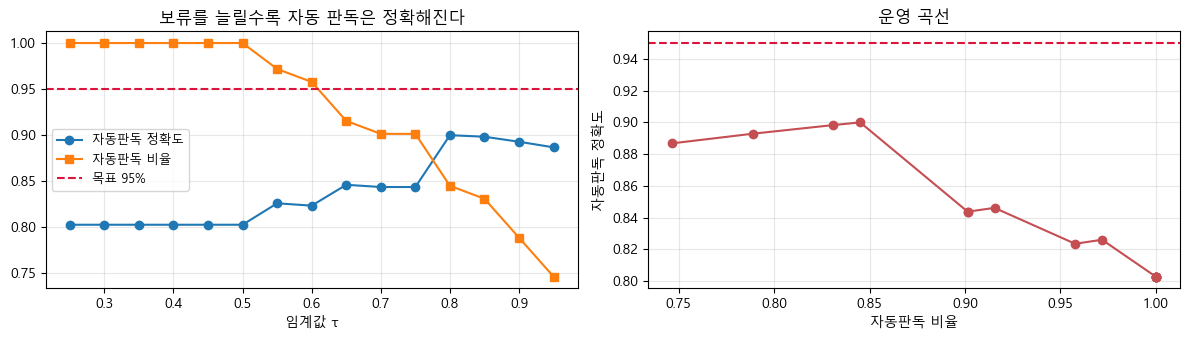

목표 정확도 95% 를 만족하는 τ 가 없다 → 현재 성능으로는 자동 판독을 권고할 수 없다.
  이것도 유효한 결론이다. 억지로 하나를 고르지 않는다.


In [36]:
conf_all = m_test['probs'].max(1); pred_all = m_test['probs'].argmax(1)
rows = []
for t_ in np.arange(0.25, 1.00, 0.05):
    keep = conf_all >= t_
    if keep.sum() == 0: continue
    rows.append({'임계값 τ': round(float(t_), 2), '자동판독 비율': float(keep.mean()),
                 '자동판독 정확도': float((pred_all[keep] == m_test['trues'][keep]).mean()),
                 '보류 건수': int((~keep).sum())})
sweep = pd.DataFrame(rows)
if len(sweep) == 0:
    sweep = pd.DataFrame([{'임계값 τ': 0.0, '자동판독 비율': 1.0,
                           '자동판독 정확도': float((pred_all == m_test['trues']).mean()),
                           '보류 건수': 0}])
display(sweep.round(4))

TARGET = 0.95
okr = sweep[sweep['자동판독 정확도'] >= TARGET]
chosen = okr.sort_values('자동판독 비율', ascending=False).iloc[0] if len(okr) else None

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(sweep['임계값 τ'], sweep['자동판독 정확도'], 'o-', label='자동판독 정확도')
ax[0].plot(sweep['임계값 τ'], sweep['자동판독 비율'], 's-', label='자동판독 비율')
ax[0].axhline(TARGET, c='crimson', ls='--', label=f'목표 {TARGET:.0%}')
if chosen is not None: ax[0].axvline(chosen['임계값 τ'], c='gray', ls=':')
ax[0].set_xlabel('임계값 τ'); ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)
ax[0].set_title('보류를 늘릴수록 자동 판독은 정확해진다')
ax[1].plot(sweep['자동판독 비율'], sweep['자동판독 정확도'], 'o-', c='#C44E52')
ax[1].axhline(TARGET, c='crimson', ls='--'); ax[1].set_xlabel('자동판독 비율')
ax[1].set_ylabel('자동판독 정확도'); ax[1].set_title('운영 곡선'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

if chosen is not None:
    print(f"τ = {chosen['임계값 τ']} → 자동판독 {chosen['자동판독 비율']:.0%}, "
          f"그 정확도 {chosen['자동판독 정확도']:.1%}, 보류 {int(chosen['보류 건수'])}건은 전문가 재확인")
else:
    print(f'목표 정확도 {TARGET:.0%} 를 만족하는 τ 가 없다 → 현재 성능으로는 자동 판독을 권고할 수 없다.')
    print('  이것도 유효한 결론이다. 억지로 하나를 고르지 않는다.')

---
# §19. 가설검정

**과제 필수 항목.** 중요한 건 "검정을 했다"가 아니라 **"이 상황에 왜 이 검정인가"** 를 설명하는 것이다.

### 검정을 고르는 기준

```
비교하려는 두 값이 같은 대상에서 나왔나?
 ├─ 예 (짝지은 자료) ─┬─ 이진 결과(맞음/틀림) → McNemar
 │                    └─ 연속값(점수)        → 대응표본 t검정 / 윌콕슨
 └─ 아니오 (독립)      ┬─ 비율 하나를 기준값과 비교 → 이항검정
                       └─ 두 비율 비교              → 두 비율 z검정
```

**같은 테스트셋을 쓴 두 모델을 독립표본 검정으로 비교하는 것이 가장 흔한 실수다.**
같은 이미지들이라 두 결과가 강하게 연관돼 있고, 그 연관을 무시하면 검정력을 잃는다.

| # | 질문 | H0 | 검정 |
|---|---|---|---|
| **1** | 전이학습이 밑바닥 CNN 보다 나은가 | 두 모델의 오분류율이 같다 | **McNemar** (같은 test, 짝지음) |
| **2** | 증강이 효과가 있는가 | 두 조건의 평균 macro-F1 이 같다 | **대응표본 t + 윌콕슨** (같은 시드끼리) |
| **3** | 모델이 "전부 호중구 찍기"보다 나은가 | 정확도 = 다수 클래스 비율 | **이항검정** (단측) |
| **4** | (부록) 증강본 무작위 검증이 부풀려졌는가 | ① 정확도 = ③ 정확도 | **두 비율 z검정** |

유의수준 α = 0.05. 검정을 여러 번 하므로 마지막에 **Holm 보정**을 한다.

In [37]:
ALPHA = 0.05
_, _, (te_x42, te_y42) = make_split(SPLIT_SEED)
L_te42 = DataLoader(BloodCellDataset(te_x42, te_y42, build_eval_tf()),
                    batch_size=BATCH_SIZE*2, shuffle=False, num_workers=NUM_WORKERS)

def load_ckpt_model(run_id):
    t = runs_table(); row = t[t.run_id == run_id].iloc[0]
    m = build_model(str(row['model']), pretrained=False, freeze=False,
                    dropout=float(row['dropout']), image_size=int(row['image_size']))
    m.load_state_dict(torch.load(f'{RESULT_DIR}/ckpt/{run_id}.pt', map_location=device))
    return m.to(device).eval()

# 두 모델 모두 split42 의 train 으로 학습하고 split42 의 val 로 선택했다.
# split42 의 test 는 여기서 처음 연다.
m_A = evaluate(load_ckpt_model('A_밑바닥CNN'), L_te42, nn.CrossEntropyLoss())
m_C = evaluate(load_ckpt_model('C+_미세조정_가중치'), L_te42, nn.CrossEntropyLoss())
print(summarize(m_C, 'C+ 미세조정+가중치'))
print(summarize(m_A, 'A 밑바닥 CNN'))

C+ 미세조정+가중치                acc 0.8310  macroF1 0.7762  balanced 0.7599  AUC 0.9343
A 밑바닥 CNN                  acc 0.7606  macroF1 0.6429  balanced 0.6032  AUC 0.8911


In [38]:
def mcnemar_test(y_true, pred_a, pred_b):
    a = (np.asarray(pred_a) == np.asarray(y_true)); b = (np.asarray(pred_b) == np.asarray(y_true))
    n01 = int((a & ~b).sum()); n10 = int((~a & b).sum()); n = n01 + n10
    if n == 0:
        stat, p, meth = 0.0, 1.0, '불일치 없음'
    elif n < 25:      # 표본이 작으면 정확 이항검정
        stat = float(min(n01, n10)); p = float(stats.binomtest(min(n01, n10), n, 0.5).pvalue)
        meth = '정확 이항검정'
    else:
        stat = (abs(n01-n10)-1)**2/n; p = float(stats.chi2.sf(stat, 1)); meth = '카이제곱(연속성 보정)'
    return dict(b=n01, c=n10, n_disc=n, statistic=float(stat), p_value=p, method=meth,
                acc_A=float(a.mean()), acc_B=float(b.mean()), diff=float(a.mean()-b.mean()),
                table=[[int((a&b).sum()), n01], [n10, int((~a&~b).sum())]])

r1 = mcnemar_test(m_C['trues'], m_C['preds'], m_A['preds'])
display(pd.DataFrame(r1['table'], index=['C+ 맞음','C+ 틀림'], columns=['A 맞음','A 틀림']))
print('=== 검정 1: McNemar ===')
print('  H0: 두 모델의 오분류율이 같다   H1: 다르다 (양측)')
print('  둘 다 맞히거나 둘 다 틀린 칸은 두 모델을 구분하는 정보가 없다 → 불일치 칸만 본다')
print(f"  b={r1['b']} (C+만 맞힘), c={r1['c']} (A만 맞힘), 불일치 {r1['n_disc']}")
print(f"  {r1['method']}  통계량 {r1['statistic']:.4f}  p = {r1['p_value']:.4e}")
print(f"  정확도 {r1['acc_A']:.4f} vs {r1['acc_B']:.4f}  차이 {r1['diff']:+.4f}")
print('  판정:', 'H0 기각 → 두 모델의 성능은 통계적으로 다르다' if r1['p_value'] < ALPHA
      else 'H0 기각 못함 → 차이를 입증하지 못했다 (test 가 71장뿐이라 검정력이 낮다)')

,A 맞음,A 틀림
C+ 맞음,49,10
C+ 틀림,5,7


=== 검정 1: McNemar ===
  H0: 두 모델의 오분류율이 같다   H1: 다르다 (양측)
  둘 다 맞히거나 둘 다 틀린 칸은 두 모델을 구분하는 정보가 없다 → 불일치 칸만 본다
  b=10 (C+만 맞힘), c=5 (A만 맞힘), 불일치 15
  정확 이항검정  통계량 5.0000  p = 3.0176e-01
  정확도 0.8310 vs 0.7606  차이 +0.0704
  판정: H0 기각 못함 → 차이를 입증하지 못했다 (test 가 71장뿐이라 검정력이 낮다)


In [39]:
# ── 검정 2 : 증강 효과 (대응표본, 시드별 검증 macro-F1)
AUG_A = BEST_PRESET if BEST_PRESET != 'none' else 'flip'
AUG_B = 'none'
pairs = []
for sd in SEEDS:
    row = {'seed': sd}
    for tag, pre in [('A', AUG_A), ('B', AUG_B)]:
        split = make_split(sd); set_seed(sd)
        l_tr, l_va, _ = make_loaders(pre, split=split)
        mdl = build_model(FINAL_CFG['model_name'], pretrained=True, freeze=False,
                          dropout=FINAL_CFG['dropout'], image_size=IMAGE_SIZE)
        cw = class_weights_from(split[0][1]) if FINAL_CFG['use_class_weight'] else None
        h = train_model(mdl, l_tr, l_va, epochs=max(SCREEN_EPOCHS, 5), lr=FINAL_CFG['lr'],
                        weight_decay=FINAL_CFG['weight_decay'], class_weight=cw,
                        scheduler=FINAL_CFG['scheduler'], patience=8,
                        ckpt_path=f'{RESULT_DIR}/ckpt/AB_{tag}_s{sd}.pt',
                        label=f'AB_{tag}_s{sd}', verbose=False)
        mdl.load_state_dict(torch.load(h['ckpt_path'], map_location=device))
        row[f'{tag}_{pre}'] = evaluate(mdl, l_va)['macro_f1']
        del mdl
        if device.type == 'cuda': torch.cuda.empty_cache()
    pairs.append(row); print(f"  seed {sd}: A({AUG_A}) {row[f'A_{AUG_A}']:.4f} | B(none) {row[f'B_{AUG_B}']:.4f}")

piv = pd.DataFrame(pairs).set_index('seed')
display(piv.round(4))
a_s, b_s = piv[f'A_{AUG_A}'].values, piv[f'B_{AUG_B}'].values

  seed 42: A(flip_rot) 0.9039 | B(none) 0.9060
  seed 0: A(flip_rot) 0.8494 | B(none) 0.7898
  seed 1: A(flip_rot) 0.7799 | B(none) 0.7232
  seed 2: A(flip_rot) 0.8634 | B(none) 0.8171
  seed 3: A(flip_rot) 0.9064 | B(none) 0.8217


,A_flip_rot,B_none
seed,,
42,0.9039,0.9060
0,0.8494,0.7898
1,0.7799,0.7232
2,0.8634,0.8171
3,0.9064,0.8217


In [40]:
d = a_s - b_s
t2, p2 = stats.ttest_rel(a_s, b_s)
try:    w2, pw2 = stats.wilcoxon(a_s, b_s)
except ValueError: w2, pw2 = float('nan'), float('nan')
sd_ = d.std(ddof=1)
ci2 = (d.mean()-1.96*sd_/np.sqrt(len(d)), d.mean()+1.96*sd_/np.sqrt(len(d)))
cohen = d.mean()/sd_ if sd_ > 0 else float('nan')

print('=== 검정 2: 대응표본 검정 (증강 있음 vs 없음) ===')
print('  H0: 두 조건의 평균 검증 macro-F1 이 같다   H1: 다르다 (양측)')
print(f'  같은 시드끼리 짝지어야 초기화·분할의 변동이 상쇄된다')
print(f'  n = {len(d)}쌍   평균 {a_s.mean():.4f} vs {b_s.mean():.4f}   차이 {d.mean():+.4f}')
print(f'  차이의 95% 신뢰구간 [{ci2[0]:+.4f}, {ci2[1]:+.4f}]')
print(f'  대응표본 t : t = {t2:.3f}, p = {p2:.4f}')
print(f'  윌콕슨     : W = {w2:.1f}, p = {pw2:.4f}   (정규성 가정이 약한 대안)')
print(f"  효과크기 Cohen's d = {cohen:.2f} "
      f"({'큼' if abs(cohen)>0.8 else '중간' if abs(cohen)>0.5 else '작음'})")
print('  판정:', 'H0 기각 → 증강이 성능에 영향을 준다' if p2 < ALPHA
      else 'H0 기각 못함 → 이 자료로는 차이를 입증하지 못했다')
print('\n  ※ "기각 못 함"은 "같다"가 아니다. 표본이 5쌍뿐이라 실제 차이도 못 잡을 수 있다.')

=== 검정 2: 대응표본 검정 (증강 있음 vs 없음) ===
  H0: 두 조건의 평균 검증 macro-F1 이 같다   H1: 다르다 (양측)
  같은 시드끼리 짝지어야 초기화·분할의 변동이 상쇄된다
  n = 5쌍   평균 0.8606 vs 0.8116   차이 +0.0490
  차이의 95% 신뢰구간 [+0.0211, +0.0770]
  대응표본 t : t = 3.438, p = 0.0263
  윌콕슨     : W = 1.0, p = 0.1250   (정규성 가정이 약한 대안)
  효과크기 Cohen's d = 1.54 (큼)
  판정: H0 기각 → 증강이 성능에 영향을 준다

  ※ "기각 못 함"은 "같다"가 아니다. 표본이 5쌍뿐이라 실제 차이도 못 잡을 수 있다.


In [41]:
# ── 검정 3 : "전부 다수 클래스로 찍기" 보다 나은가 (이항검정, 단측)
k = int((m_C['preds'] == m_C['trues']).sum()); n = len(m_C['trues'])
p0 = float(major)
bt = stats.binomtest(k, n, p0, alternative='greater')
print('=== 검정 3: 이항검정 (단측) ===')
print(f'  H0: 모델 정확도 = {p0:.4f} (전부 {KOR[CLASS_NAMES[int(cnt.argmax())]]}로 찍기)')
print(f'  H1: 모델 정확도 > {p0:.4f}')
print(f'  관측 {k}/{n} = {k/n:.4f}')
try:
    ci_ = tuple(np.round(bt.proportion_ci(0.95), 4))
except Exception:
    ci_ = '(scipy 버전이 낮아 생략)'
print(f'  p = {bt.pvalue:.4e}   95% 신뢰구간 {ci_}')
p3 = float(bt.pvalue)
print('  판정:', 'H0 기각 → 모델이 다수 클래스 찍기보다 유의하게 낫다' if p3 < ALPHA
      else 'H0 기각 못함 → 다수 클래스 찍기보다 낫다고 말할 수 없다')

=== 검정 3: 이항검정 (단측) ===
  H0: 모델 정확도 = 0.5932 (전부 호중구로 찍기)
  H1: 모델 정확도 > 0.5932
  관측 59/71 = 0.8310
  p = 1.5229e-05   95% 신뢰구간 (0.7406, 1.0)
  판정: H0 기각 → 모델이 다수 클래스 찍기보다 유의하게 낫다


---
# §20. 부록 — 증강본 12,444장을 왜 안 쓰는가  🔁

§0 에서 "증강본을 쓰면 누수가 생긴다"고 했다. **말이 아니라 숫자로 보인다.**

증강본으로 학습하고 **두 가지 시험지**로 채점한다.

| 시험지 | 만드는 법 | 누수 위험 |
|---|---|---|
| **① 무작위 검증** | 증강본 TRAIN 을 무작위 8:2 로 나눈 것 | **높음** — 같은 원본의 형제 사진이 양쪽에 들어간다 |
| **③ 공식 TEST** | `dataset2-master/images/TEST` 폴더 | 낮음 — 제작자가 따로 만든 시험지 |

**①이 ③보다 크게 높다면, ①은 외운 것을 다시 물어본 시험이다.**
그리고 그런 시험지로 하이퍼파라미터를 고르면 잘못된 설정을 고르게 된다.

> 이 셀은 시간이 좀 걸린다(증강본 9,957장). 건너뛰려면 `RUN_APPENDIX = False`.

In [42]:
RUN_APPENDIX = True
APPENDIX_EPOCHS = 3

appendix_done = False
if RUN_APPENDIX and os.path.isdir(AUG_DIR):
    aug_rows = []
    for split_name in ['TRAIN', 'TEST']:
        for c in CLASS_NAMES:
            d_ = os.path.join(AUG_DIR, split_name, c)
            for f_ in sorted(os.listdir(d_)):
                aug_rows.append({'path': os.path.join(d_, f_), 'split': split_name,
                                 'label': CLS2IDX[c]})
    aug = pd.DataFrame(aug_rows)
    piv_a = aug.pivot_table(index='label', columns='split', values='path', aggfunc='count')
    piv_a.index = [f'{c}({KOR[c]})' for c in CLASS_NAMES]
    piv_a['원본'] = cnt
    piv_a['증강배율'] = ((piv_a['TRAIN']+piv_a['TEST'])/piv_a['원본']).round(1)
    display(piv_a[['원본','TRAIN','TEST','증강배율']])
    print('★ 균형이 맞아 보이지만, 단핵구는 21장을 150배로 복사한 것이다. 정보량은 여전히 21 대 207이다.')
    appendix_done = True
else:
    print('증강본 폴더가 없거나 RUN_APPENDIX=False — 부록을 건너뛴다')

split,원본,TRAIN,TEST,증강배율
EOSINOPHIL(호산구),90,2497,623,34.7
LYMPHOCYTE(림프구),34,2483,620,91.3
MONOCYTE(단핵구),20,2478,620,154.9
NEUTROPHIL(호중구),210,2499,624,14.9


★ 균형이 맞아 보이지만, 단핵구는 21장을 150배로 복사한 것이다. 정보량은 여전히 21 대 207이다.


In [43]:
if appendix_done:
    tr_pool = aug[aug.split == 'TRAIN']
    te_pool = aug[aug.split == 'TEST']
    ax_tr, ax_va, ay_tr, ay_va = train_test_split(
        tr_pool['path'].values, tr_pool['label'].values,
        test_size=0.2, stratify=tr_pool['label'].values, random_state=42)

    set_seed(42)
    kw = dict(num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))
    l_fit  = DataLoader(BloodCellDataset(ax_tr, ay_tr, build_train_tf(BEST_PRESET)),
                        batch_size=64, shuffle=True, **kw)
    l_rand = DataLoader(BloodCellDataset(ax_va, ay_va, build_eval_tf()),
                        batch_size=128, shuffle=False, **kw)
    l_off  = DataLoader(BloodCellDataset(te_pool['path'].values, te_pool['label'].values,
                                         build_eval_tf()), batch_size=128, shuffle=False, **kw)
    print(f'학습 {len(ax_tr)}장 / ① 무작위 검증 {len(ax_va)}장 / ③ 공식 TEST {len(te_pool)}장')

    mdl = build_model(FINAL_CFG['model_name'], pretrained=True, freeze=False,
                      dropout=FINAL_CFG['dropout'], image_size=IMAGE_SIZE)
    h = train_model(mdl, l_fit, l_rand, epochs=APPENDIX_EPOCHS, lr=FINAL_CFG['lr'],
                    scheduler='plateau', patience=APPENDIX_EPOCHS,
                    ckpt_path=f'{RESULT_DIR}/ckpt/APPENDIX.pt', label='부록_증강본')
    mdl.load_state_dict(torch.load(h['ckpt_path'], map_location=device))
    m_rand = evaluate(mdl, l_rand, nn.CrossEntropyLoss())
    m_off  = evaluate(mdl, l_off,  nn.CrossEntropyLoss())
    print()
    print(summarize(m_rand, '① 무작위 검증'))
    print(summarize(m_off,  '③ 공식 TEST'))
    del mdl
    if device.type == 'cuda': torch.cuda.empty_cache()

학습 7965장 / ① 무작위 검증 1992장 / ③ 공식 TEST 2487장
[부록_증강본]  1/3 loss 0.2570 acc 0.8965 | val_loss 0.1270 val_acc 0.9503 val_macroF1 0.9498 | lr 3.0e-04 (34.7s) 저장
[부록_증강본]  2/3 loss 0.0305 acc 0.9901 | val_loss 0.0156 val_acc 0.9970 val_macroF1 0.9970 | lr 3.0e-04 (30.4s) 저장
[부록_증강본]  3/3 loss 0.0225 acc 0.9940 | val_loss 0.0097 val_acc 0.9980 val_macroF1 0.9980 | lr 3.0e-04 (30.4s) 저장
best 검증 macro-F1 = 0.9980 @epoch 3
에폭당 평균 31.8초 (예산 180초) | 총 3에폭 1.6분

① 무작위 검증                   acc 0.9980  macroF1 0.9980  balanced 0.9980  AUC 1.0000
③ 공식 TEST                  acc 0.8335  macroF1 0.8358  balanced 0.8336  AUC 0.9507


=== 검정 4: 두 비율 z검정 — ① 무작위 검증 vs ③ 공식 TEST ===
  H0: 두 시험지의 정확도가 같다   H1: 다르다 (양측)
  서로 다른 표본이므로 McNemar 가 아니라 두 비율 검정을 쓴다
  ① 무작위 검증 : 1988/1992 = 0.9980
  ③ 공식 TEST   : 2073/2487 = 0.8335
  차이 +0.1645  95% 신뢰구간 [+0.1497, +0.1792]
  z = 18.803  p = 7.1642e-79

  ▶ ① 이 ③ 보다 유의하게 높다 = **무작위 분할 검증이 성능을 부풀린다.**
     같은 원본에서 나온 형제 사진이 학습과 검증에 함께 들어갔기 때문이다.
     → 원본 354장만 쓰기로 한 이 노트북의 결정이 데이터로 정당화됐다.


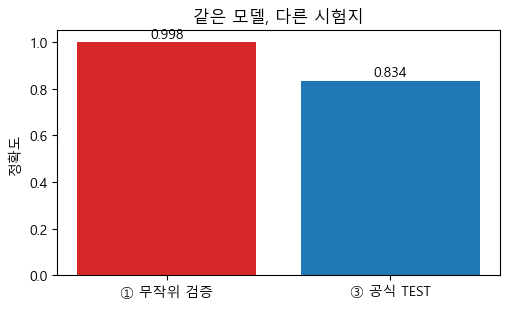

In [44]:
p4 = None
if appendix_done:
    k1 = int((m_rand['preds'] == m_rand['trues']).sum()); n1 = len(m_rand['trues'])
    k2 = int((m_off['preds']  == m_off['trues']).sum());  n2 = len(m_off['trues'])
    p1_, p2_ = k1/n1, k2/n2
    pp = (k1+k2)/(n1+n2); se = math.sqrt(pp*(1-pp)*(1/n1+1/n2))
    z = (p1_-p2_)/se if se > 0 else 0.0
    p4 = float(2*stats.norm.sf(abs(z)))
    se_d = math.sqrt(p1_*(1-p1_)/n1 + p2_*(1-p2_)/n2)

    print('=== 검정 4: 두 비율 z검정 — ① 무작위 검증 vs ③ 공식 TEST ===')
    print('  H0: 두 시험지의 정확도가 같다   H1: 다르다 (양측)')
    print('  서로 다른 표본이므로 McNemar 가 아니라 두 비율 검정을 쓴다')
    print(f'  ① 무작위 검증 : {k1}/{n1} = {p1_:.4f}')
    print(f'  ③ 공식 TEST   : {k2}/{n2} = {p2_:.4f}')
    print(f'  차이 {p1_-p2_:+.4f}  95% 신뢰구간 [{p1_-p2_-1.96*se_d:+.4f}, {p1_-p2_+1.96*se_d:+.4f}]')
    print(f'  z = {z:.3f}  p = {p4:.4e}')
    print()
    if p4 < ALPHA and p1_ > p2_:
        print('  ▶ ① 이 ③ 보다 유의하게 높다 = **무작위 분할 검증이 성능을 부풀린다.**')
        print('     같은 원본에서 나온 형제 사진이 학습과 검증에 함께 들어갔기 때문이다.')
        print('     → 원본 354장만 쓰기로 한 이 노트북의 결정이 데이터로 정당화됐다.')
    else:
        print('  ▶ 차이를 입증하지 못했다. 다만 "누수가 없다"는 증거는 아니다.')

    plt.figure(figsize=(5.2, 3.2))
    plt.bar(['① 무작위 검증','③ 공식 TEST'], [p1_, p2_], color=['tab:red','tab:blue'])
    plt.ylabel('정확도'); plt.ylim(0, 1.05); plt.title('같은 모델, 다른 시험지')
    for i, v in enumerate([p1_, p2_]): plt.text(i, v+0.02, f'{v:.3f}', ha='center')
    plt.tight_layout(); plt.show()

### 부록의 결론

- 증강본을 쓰면 **데이터는 35배 많아지지만 정보량은 그대로**다(366장의 회전본).
- 무작위로 나눈 검증셋은 **외운 것을 다시 물어보는 시험**이 되어 점수를 부풀린다.
- 그런 시험지로 하이퍼파라미터를 고르면 **"증강을 하지 마라"** 같은 잘못된 결론이 나온다.

> **그래서 이 노트북의 본문은 원본 354장만 쓴다.** 데이터는 적지만 **점수를 믿을 수 있다.**

## 다중비교 보정 (Holm-Bonferroni)

검정을 여러 번 하면 실제로 아무 차이가 없어도 하나가 우연히 p<0.05 가 될 확률이 올라간다
(4번이면 약 18.5%). p값을 작은 것부터 정렬해 $k$번째에 $(m-k+1)$ 을 곱해 보정한다.

In [45]:
def holm(pvals, names, alpha=0.05):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for rank, i in enumerate(order):
        run = max(run, (m-rank)*p[i]); adj[i] = min(run, 1.0)
    return pd.DataFrame({'가설': names, 'p (원본)': p, 'p (Holm 보정)': adj,
                         '판정': np.where(adj < alpha, '유의 (H0 기각)', '유의하지 않음')})

tests = [('1. 전이학습 vs 밑바닥CNN (McNemar)', r1['p_value']),
         ('2. 증강 효과 (대응표본 t)',           float(p2)),
         ('3. 다수클래스 찍기 대비 (이항검정)',   p3)]
if p4 is not None:
    tests.append(('4. ①무작위검증 vs ③공식TEST (두 비율)', p4))
res_h = holm([p for _, p in tests], [n for n, _ in tests], ALPHA)
display(res_h.style.format({'p (원본)': '{:.3e}', 'p (Holm 보정)': '{:.3e}'}))

,가설,p (원본),p (Holm 보정),판정
0,1. 전이학습 vs 밑바닥CNN (McNemar),3.018e-01,3.018e-01,유의하지 않음
1,2. 증강 효과 (대응표본 t),2.635e-02,5.270e-02,유의하지 않음
2,3. 다수클래스 찍기 대비 (이항검정),1.523e-05,4.569e-05,유의 (H0 기각)
3,4. ①무작위검증 vs ③공식TEST (두 비율),7.164e-79,2.866e-78,유의 (H0 기각)


---
# §21. 최종 결론

In [46]:
summary = pd.DataFrame([
    dict(구분='무작위로 찍기',                정확도=1/NUM_CLASSES, macroF1=np.nan, 근거='이론값'),
    dict(구분=f'전부 {KOR[CLASS_NAMES[int(cnt.argmax())]]}로 찍기 (기준선 0)',
         정확도=major, macroF1=np.nan, 근거='수업 4-2'),
    dict(구분='A. 밑바닥 CNN',               정확도=m_A['accuracy'], macroF1=m_A['macro_f1'], 근거='수업 4-4'),
    dict(구분='C+. 미세조정 + 클래스가중치',   정확도=m_C['accuracy'], macroF1=m_C['macro_f1'], 근거='수업 4-6/4-7/5-3'),
    dict(구분=f'★ 최종 (반복 홀드아웃 {len(SEEDS)}회 평균)',
         정확도=rep.test_accuracy.mean(), macroF1=rep.test_macro_f1.mean(), 근거='수업 4-3'),
]).round(4)
display(summary)

print('=' * 78)
print(f"최종 모델 : {FINAL_CFG['model_name']} | 증강 {FINAL_CFG['preset']} | {IMAGE_SIZE}px "
      f"| lr {FINAL_CFG['lr']:g} | {FINAL_CFG['scheduler']} "
      f"| dropout {FINAL_CFG['dropout']} | 클래스가중치 {FINAL_CFG['use_class_weight']}")
print(f"TEST 정확도  {rep.test_accuracy.mean():.4f} ± {rep.test_accuracy.std():.4f}")
print(f"TEST macro-F1 {rep.test_macro_f1.mean():.4f} ± {rep.test_macro_f1.std():.4f}")
print(f"TEST 균형정확도 {rep.test_balanced.mean():.4f} ± {rep.test_balanced.std():.4f}")
print(f"에폭당 {rep.epoch_sec.mean():.1f}초 / 예산 {EPOCH_BUDGET}초 → "
      f"{'조건 충족' if rep.epoch_sec.max() <= EPOCH_BUDGET else '조건 위반'}")
print(f"총 실험 {len(runs_table())}건 (results/runs.csv)")
print('=' * 78)
runs_table().to_csv(f'{RESULT_DIR}/전체실험기록.csv', index=False, encoding='utf-8-sig')
rep.to_csv(f'{RESULT_DIR}/최종_반복홀드아웃.csv', index=False, encoding='utf-8-sig')

,구분,정확도,macroF1,근거
0,무작위로 찍기,0.2500,NaN,이론값
1,전부 호중구로 찍기 (기준선 0),0.5932,NaN,수업 4-2
2,A. 밑바닥 CNN,0.7606,0.6429,수업 4-4
3,C+. 미세조정 + 클래스가중치,0.8310,0.7762,수업 4-6/4-7/5-3
4,★ 최종 (반복 홀드아웃 5회 평균),0.8507,0.8010,수업 4-3


최종 모델 : resnet18 | 증강 flip_rot | 224px | lr 0.0003 | cosine | dropout 0.5 | 클래스가중치 False
TEST 정확도  0.8507 ± 0.0514
TEST macro-F1 0.8010 ± 0.0803
TEST 균형정확도 0.7911 ± 0.0759
에폭당 1.4초 / 예산 180초 → 조건 충족
총 실험 24건 (results/runs.csv)


## 누수 방지 대조표 — 무엇을 어떻게 막았나

| 누수 가능성 | 이 노트북의 대응 |
|---|---|
| 같은 원본의 형제 사진이 학습·시험에 나뉘어 들어감 | **원본 354장만 사용.** 한 장이 곧 하나의 촬영이라 형제가 생길 수 없다 (§0, §6) |
| 분할이 겹침 | `train_test_split` 두 번 + **경로 교집합 0 확인** (§6) |
| 검증·시험 데이터에 증강이 걸림 | 학습 변환과 평가 변환을 분리 (§5) |
| 테스트를 보고 모델·파라미터를 고름 | §10~§14 는 **전부 검증셋으로만** 판단. test 는 §15 에서 처음 열었다 |
| 테스트로 임계값을 맞춤 | τ 는 **결과 보고용 곡선**이며, 이 값으로 모델을 다시 고르지 않았다 (§18) |
| 한 번의 분할 결과를 일반화 | **시드를 바꿔 5회 반복**, 평균 ± 표준편차로 보고 (§15) |
| 라벨을 추측해서 채움 | 다중 라벨·BASOPHIL 은 제외. 추측하지 않았다 (§3) |

## 수업 내용 대조표

| 수업 | 항목 | 이 노트북 |
|---|---|---|
| 1장 | `device`, `cuda.synchronize()` | §2, §9 |
| 2-1 | 시드 고정 | §2, §15 |
| 2-3 | `nn.Module` | §7 |
| 2-4 | `Dataset` / `DataLoader` | §6 |
| **2-5** | **학습 루프 다섯 줄** | **§8** |
| 2-6 | `state_dict` 저장 | §8 |
| 2-8 | `eval()`+`no_grad()`, 혼동행렬, ROC | §8, §16 |
| 2-9 | 스케줄러 | §8, §13 |
| 2-10 | BatchNorm / Dropout | §7, §13 |
| 3-10 | 오분류 들여다보기 | §16 |
| 3-12 | CNN 쌓기 | §7 |
| 3-13 | 데이터 증강 (테스트는 증강 안 함) | §5 |
| 3-15 | 스케줄러 3종 | §13 |
| **4-2** | **클래스 불균형 확인 → 기준선 0** | **§3** |
| **4-3** | **층화 3분할** | **§6, §15** |
| **4-4** | **밑바닥 CNN = 기준선** | **§10 A** |
| **4-5** | **정확도만으로 부족** | **§3, §10, §16** |
| **4-6** | **전이학습 백본 고정** | **§10 B** |
| **4-7** | **클래스 가중치** | **§10 C+, §13** |
| 5-3 | 전체 미세조정, 작은 학습률 | §10 C, §13 |
| 5-4 | 체크포인트, 분모 확인 | §8, §16 |
| **5.ipynb** | **Grad-CAM, 임계값 스윕** | **§17, §18** |
| 영상처리 2-9 | 소벨 엣지 | §4 |

## 보고서 뼈대

1. **문제** — 말초혈액 도말에서 백혈구 4종 분류. BASOPHIL 은 3장이라 제외 (§3)
2. **데이터 선택** — 증강본 12,444장 대신 **원본 354장**. 이유는 누수 (§0, §20)
3. **기준선** — 무작위 0.25 / 전부 호중구 0.59. 이 위에서 읽는다 (§3)
4. **베이스라인 3단** — 밑바닥 CNN → 백본 고정 → 미세조정 + 클래스 가중치 (§10, 수업 4장 구조)
5. **선택** — 전부 검증셋으로. test 는 §15 에서 한 번 (§12~§14)
6. **성능** — TEST 정확도 X ± s, macro-F1 Y ± s (§15)
7. **근거** — Grad-CAM 으로 세포를 보는지 확인 (§17)
8. **운영** — 확신도 임계값 τ 운영 곡선 (§18)
9. **검정** — 자료 구조에 맞는 검정 + Holm 보정 (§19)
10. **한계** — ① 단핵구 21장으로 표본 부족 ② 환자 ID 부재 ③ 단일 장비·단일 염색 조건
    ④ BASOPHIL 미포함 ⑤ test 71장이라 신뢰구간이 넓다

> **"이게 베스트다"라고 말할 때 반드시 함께 말할 것**
> 어떤 후보들과 비교했는지 · 어떤 기준으로 골랐는지 · 그 차이가 통계적으로 유의한지 ·
> 그리고 **어떤 시험지에서 잰 숫자인지**.